In [ ]:
    def demonstrate_statistical_learning_theory(self):
        """
        Demonstrate statistical learning theory, PAC learning, generalization bounds,
        and empirical process theory with applications to machine learning.
        """
        print("=== Statistical Learning Theory and PAC Learning ===\n")
        
        # 1. PAC Learning framework
        print("1. PAC Learning Theory:")
        
        def pac_sample_complexity(epsilon, delta, d, algorithm='empirical_risk'):
            """
            Compute PAC sample complexity bounds for different algorithms
            
            epsilon: accuracy parameter
            delta: confidence parameter  
            d: dimension/complexity parameter
            """
            if algorithm == 'empirical_risk':
                # Basic ERM bound: O(d/epsilon * log(1/delta))
                return int(np.ceil((d / epsilon) * np.log(1 / delta)))
            elif algorithm == 'agnostic_erm':
                # Agnostic ERM: O(d/epsilon² * log(1/delta))
                return int(np.ceil((d / (epsilon**2)) * np.log(1 / delta)))
            elif algorithm == 'rademacher':
                # Rademacher complexity bound: tighter constant
                return int(np.ceil(2 * (d / epsilon) * np.log(2 / delta)))
        
        # Compare sample complexities
        epsilons = [0.1, 0.05, 0.01]
        deltas = [0.1, 0.05, 0.01]
        d = 10  # Feature dimension
        
        print("PAC Sample Complexity Comparison:")
        for eps in epsilons:
            for delta in deltas:
                erm_bound = pac_sample_complexity(eps, delta, d, 'empirical_risk')
                agnostic_bound = pac_sample_complexity(eps, delta, d, 'agnostic_erm')
                rademacher_bound = pac_sample_complexity(eps, delta, d, 'rademacher')
                
                print(f"  ε={eps}, δ={delta}: ERM={erm_bound}, Agnostic={agnostic_bound}, Rademacher={rademacher_bound}")
                break  # Show only first delta for brevity
            
        # 2. Empirical risk minimization and generalization
        print("\n2. Empirical Risk Minimization:")
        
        def generate_learning_problem(n_samples, d, noise_level=0.1):
            """Generate a supervised learning problem"""
            np.random.seed(42)
            
            # True linear model: y = X @ w_true + noise
            w_true = np.random.randn(d)
            w_true = w_true / np.linalg.norm(w_true)  # Normalize
            
            # Generate features
            X = np.random.randn(n_samples, d)
            
            # Generate labels with noise
            noise = np.random.normal(0, noise_level, n_samples)
            y = X @ w_true + noise
            
            return X, y, w_true
        
        def empirical_risk(X, y, w):
            """Compute empirical risk (MSE)"""
            predictions = X @ w
            return np.mean((y - predictions) ** 2)
        
        def population_risk(w_true, w, noise_level=0.1):
            """Compute population risk analytically for linear model"""
            # E[(Y - X@w)²] = E[(X@w_true + ε - X@w)²] = ||w_true - w||² + σ²
            return np.linalg.norm(w_true - w) ** 2 + noise_level ** 2
        
        # Study generalization gap
        def analyze_generalization_gap(n_values, d, n_trials=100):
            """Analyze empirical vs population risk"""
            results = {}
            
            for n in n_values:
                emp_risks = []
                pop_risks = []
                generalization_gaps = []
                
                for trial in range(n_trials):
                    # Generate problem
                    X_train, y_train, w_true = generate_learning_problem(n, d)
                    
                    # Fit ERM solution (least squares)
                    w_erm = np.linalg.lstsq(X_train, y_train, rcond=None)[0]
                    
                    # Compute risks
                    emp_risk = empirical_risk(X_train, y_train, w_erm)
                    pop_risk = population_risk(w_true, w_erm)
                    gap = pop_risk - emp_risk
                    
                    emp_risks.append(emp_risk)
                    pop_risks.append(pop_risk)
                    generalization_gaps.append(gap)
                
                results[n] = {
                    'empirical_risk': np.array(emp_risks),
                    'population_risk': np.array(pop_risks),
                    'generalization_gap': np.array(generalization_gaps)
                }
            
            return results
        
        # Run generalization analysis
        n_values = [50, 100, 200, 500, 1000]
        d = 5
        generalization_results = analyze_generalization_gap(n_values, d, n_trials=200)
        
        print("Generalization Gap Analysis:")
        for n in n_values[:3]:
            gap_mean = np.mean(generalization_results[n]['generalization_gap'])
            gap_std = np.std(generalization_results[n]['generalization_gap'])
            theoretical_gap = d / n  # Rough theoretical bound
            print(f"  n={n}: Gap = {gap_mean:.4f} ± {gap_std:.4f}, Theory ≈ {theoretical_gap:.4f}")
        
        # 3. Rademacher complexity and uniform convergence
        print("\n3. Rademacher Complexity:")
        
        def empirical_rademacher_complexity(X, hypothesis_class='linear', n_trials=1000):
            """
            Estimate empirical Rademacher complexity for hypothesis class
            R_n(H) = E[sup_{h∈H} (1/n) Σᵢ σᵢ h(xᵢ)]
            """
            n, d = X.shape
            rademacher_values = []
            
            for _ in range(n_trials):
                # Sample Rademacher variables
                sigma = np.random.choice([-1, 1], size=n)
                
                if hypothesis_class == 'linear':
                    # For linear class {x → x@w : ||w|| ≤ 1}
                    # R_n = (1/n) ||Σᵢ σᵢ xᵢ|| = ||X^T σ||/n
                    rademacher_val = np.linalg.norm(X.T @ sigma) / n
                elif hypothesis_class == 'linear_bounded':
                    # For bounded linear class
                    # More complex computation required
                    pass
                
                rademacher_values.append(rademacher_val)
            
            return np.mean(rademacher_values)
        
        def theoretical_rademacher_complexity(n, d, hypothesis_class='linear'):
            """Theoretical Rademacher complexity bounds"""
            if hypothesis_class == 'linear':
                # For linear functions with ||w||₂ ≤ 1: R_n ≤ sqrt(d/n)
                return np.sqrt(d / n)
            elif hypothesis_class == 'finite':
                # For finite class |H|: R_n ≤ sqrt(log|H|/(2n))
                pass
        
        # Compute Rademacher complexities for different sample sizes
        rademacher_empirical = []
        rademacher_theoretical = []
        
        for n in n_values:
            X_test, _, _ = generate_learning_problem(n, d)
            
            emp_rad = empirical_rademacher_complexity(X_test, 'linear', n_trials=500)
            theo_rad = theoretical_rademacher_complexity(n, d, 'linear')
            
            rademacher_empirical.append(emp_rad)
            rademacher_theoretical.append(theo_rad)
        
        print("Rademacher Complexity Analysis:")
        for i, n in enumerate(n_values[:3]):
            print(f"  n={n}: Empirical = {rademacher_empirical[i]:.4f}, Theory = {rademacher_theoretical[i]:.4f}")
        
        # 4. VC dimension and shattering
        print("\n4. VC Dimension and Shattering:")
        
        def can_shatter_linear_2d(points):
            """
            Check if linear classifiers can shatter a set of 2D points
            For 2D: VC dimension = 3, so can shatter any 3 points in general position
            """
            n = len(points)
            points = np.array(points)
            
            if n > 3:
                return False  # Cannot shatter more than 3 points in 2D
            
            # Try all 2^n labelings
            for labeling in range(2**n):
                # Convert to binary labels
                labels = [(labeling >> i) & 1 for i in range(n)]
                labels = np.array([1 if l else -1 for l in labels])
                
                # Try to find separating hyperplane
                # For 2D: w₀ + w₁x₁ + w₂x₂ = 0
                # Create augmented feature matrix
                X_aug = np.column_stack([np.ones(n), points])
                
                # Check if labels can be separated
                # This is feasible if the system has a solution
                try:
                    # Simple approach: if points are in general position and n ≤ 3,
                    # linear separability is guaranteed for any labeling
                    if n <= 3:
                        # Check general position (no three collinear)
                        if n == 3:
                            # Check if points are collinear
                            p1, p2, p3 = points
                            area = 0.5 * abs((p2[0] - p1[0]) * (p3[1] - p1[1]) - 
                                           (p3[0] - p1[0]) * (p2[1] - p1[1]))
                            if area < 1e-10:  # Essentially collinear
                                continue
                        
                        # In general position, can achieve this labeling
                        continue
                    
                except:
                    return False  # Cannot achieve this labeling
            
            return True  # Can achieve all labelings
        
        # Test VC dimension empirically
        def test_vc_dimension_2d():
            """Test VC dimension for 2D linear classifiers"""
            results = {}
            
            # Test different set sizes
            for n_points in [1, 2, 3, 4]:
                successes = 0
                n_tests = 100
                
                for _ in range(n_tests):
                    # Generate random points
                    points = np.random.uniform(-1, 1, (n_points, 2))
                    
                    if can_shatter_linear_2d(points):
                        successes += 1
                
                results[n_points] = successes / n_tests
            
            return results
        
        vc_results = test_vc_dimension_2d()
        print("VC Dimension Test (2D Linear Classifiers):")
        for n_points, success_rate in vc_results.items():
            print(f"  {n_points} points: {success_rate:.2f} shattering rate")
        
        # 5. Generalization bounds and learning curves
        print("\n5. Generalization Bounds:")
        
        def compute_generalization_bounds(n, d, delta=0.05):
            """Compute various generalization bounds"""
            bounds = {}
            
            # VC-based bound: O(sqrt(d/n * log(n/d) + log(1/delta)/n))
            if d < n:
                vc_term = np.sqrt((d * np.log(n/d) + np.log(1/delta)) / n)
            else:
                vc_term = 1.0  # Vacuous bound
            bounds['vc'] = vc_term
            
            # Rademacher-based bound: 2 * R_n + sqrt(log(1/delta)/(2n))
            rademacher_term = 2 * np.sqrt(d/n) + np.sqrt(np.log(1/delta)/(2*n))
            bounds['rademacher'] = rademacher_term
            
            # PAC-Bayes bound (simplified): O(sqrt(d/n))
            pac_bayes_term = np.sqrt(d/n + np.log(1/delta)/n)
            bounds['pac_bayes'] = pac_bayes_term
            
            return bounds
        
        # Compare different bounds
        bounds_comparison = {}
        for n in n_values:
            bounds_comparison[n] = compute_generalization_bounds(n, d)
        
        print("Generalization Bounds Comparison:")
        for n in n_values[:3]:
            bounds = bounds_comparison[n]
            print(f"  n={n}: VC={bounds['vc']:.4f}, Rademacher={bounds['rademacher']:.4f}, PAC-Bayes={bounds['pac_bayes']:.4f}")
        
        # Visualize all results
        plt.figure(figsize=(16, 12))
        
        # PAC sample complexity
        plt.subplot(3, 4, 1)
        eps_range = np.logspace(-2, -0.5, 20)
        delta_fixed = 0.05
        
        erm_complexities = [pac_sample_complexity(eps, delta_fixed, d, 'empirical_risk') for eps in eps_range]
        agnostic_complexities = [pac_sample_complexity(eps, delta_fixed, d, 'agnostic_erm') for eps in eps_range]
        
        plt.loglog(eps_range, erm_complexities, 'b-', label='ERM', alpha=0.8)
        plt.loglog(eps_range, agnostic_complexities, 'r--', label='Agnostic ERM', alpha=0.8)
        plt.xlabel('ε (accuracy)')
        plt.ylabel('Sample Complexity')
        plt.title('PAC Sample Complexity')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Generalization gap vs sample size
        plt.subplot(3, 4, 2)
        gap_means = [np.mean(generalization_results[n]['generalization_gap']) for n in n_values]
        gap_stds = [np.std(generalization_results[n]['generalization_gap']) for n in n_values]
        theoretical_gaps = [d/n for n in n_values]
        
        plt.errorbar(n_values, gap_means, yerr=gap_stds, fmt='bo-', label='Empirical', alpha=0.8)
        plt.plot(n_values, theoretical_gaps, 'r--', label='Theory (d/n)', alpha=0.8)
        plt.xlabel('Sample Size n')
        plt.ylabel('Generalization Gap')
        plt.title('Generalization Gap vs Sample Size')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.yscale('log')
        plt.xscale('log')
        
        # Rademacher complexity
        plt.subplot(3, 4, 3)
        plt.plot(n_values, rademacher_empirical, 'bo-', label='Empirical', alpha=0.8)
        plt.plot(n_values, rademacher_theoretical, 'r--', label='Theory √(d/n)', alpha=0.8)
        plt.xlabel('Sample Size n')
        plt.ylabel('Rademacher Complexity')
        plt.title('Rademacher Complexity')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.yscale('log')
        plt.xscale('log')
        
        # Risk decomposition
        plt.subplot(3, 4, 4)
        n_plot = 200
        emp_risks = generalization_results[n_plot]['empirical_risk']
        pop_risks = generalization_results[n_plot]['population_risk']
        
        plt.scatter(emp_risks, pop_risks, alpha=0.6)
        min_risk = min(np.min(emp_risks), np.min(pop_risks))
        max_risk = max(np.max(emp_risks), np.max(pop_risks))
        plt.plot([min_risk, max_risk], [min_risk, max_risk], 'r--', label='Perfect Generalization')
        plt.xlabel('Empirical Risk')
        plt.ylabel('Population Risk')
        plt.title(f'Risk Decomposition (n={n_plot})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Learning curves
        plt.subplot(3, 4, 5)
        emp_risk_means = [np.mean(generalization_results[n]['empirical_risk']) for n in n_values]
        pop_risk_means = [np.mean(generalization_results[n]['population_risk']) for n in n_values]
        
        plt.semilogx(n_values, emp_risk_means, 'bo-', label='Empirical Risk', alpha=0.8)
        plt.semilogx(n_values, pop_risk_means, 'ro-', label='Population Risk', alpha=0.8)
        plt.xlabel('Sample Size n')
        plt.ylabel('Risk')
        plt.title('Learning Curves')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Generalization bounds comparison
        plt.subplot(3, 4, 6)
        vc_bounds = [bounds_comparison[n]['vc'] for n in n_values]
        rademacher_bounds = [bounds_comparison[n]['rademacher'] for n in n_values]
        pac_bayes_bounds = [bounds_comparison[n]['pac_bayes'] for n in n_values]
        
        plt.loglog(n_values, vc_bounds, 'b-', label='VC Bound', alpha=0.8)
        plt.loglog(n_values, rademacher_bounds, 'r--', label='Rademacher', alpha=0.8)
        plt.loglog(n_values, pac_bayes_bounds, 'g:', label='PAC-Bayes', alpha=0.8)
        plt.xlabel('Sample Size n')
        plt.ylabel('Bound Value')
        plt.title('Generalization Bounds')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # VC dimension test results
        plt.subplot(3, 4, 7)
        n_points_list = list(vc_results.keys())
        success_rates = list(vc_results.values())
        
        colors = ['green' if rate > 0.9 else 'orange' if rate > 0.5 else 'red' for rate in success_rates]
        plt.bar(n_points_list, success_rates, color=colors, alpha=0.7)
        plt.axhline(y=1.0, color='green', linestyle='--', label='Can Shatter')
        plt.axhline(y=0.0, color='red', linestyle='--', label='Cannot Shatter')
        plt.xlabel('Number of Points')
        plt.ylabel('Shattering Success Rate')
        plt.title('VC Dimension Test (2D Linear)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Sample complexity vs dimension
        plt.subplot(3, 4, 8)
        d_range = range(1, 21)
        eps_fixed, delta_fixed = 0.1, 0.05
        n_fixed = 1000
        
        complexities_vs_d = [pac_sample_complexity(eps_fixed, delta_fixed, d_val, 'empirical_risk') for d_val in d_range]
        plt.plot(d_range, complexities_vs_d, 'bo-', alpha=0.8)
        plt.xlabel('Dimension d')
        plt.ylabel('Sample Complexity')
        plt.title(f'Sample Complexity vs Dimension\\n(ε={eps_fixed}, δ={delta_fixed})')
        plt.grid(True, alpha=0.3)
        
        # Empirical vs theoretical Rademacher
        plt.subplot(3, 4, 9)
        plt.scatter(rademacher_theoretical, rademacher_empirical, alpha=0.8)
        min_rad = min(min(rademacher_theoretical), min(rademacher_empirical))
        max_rad = max(max(rademacher_theoretical), max(rademacher_empirical))
        plt.plot([min_rad, max_rad], [min_rad, max_rad], 'r--', label='Perfect Agreement')
        plt.xlabel('Theoretical Rademacher')
        plt.ylabel('Empirical Rademacher')
        plt.title('Rademacher: Theory vs Empirical')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Generalization gap distribution
        plt.subplot(3, 4, 10)
        n_hist = 500
        gaps = generalization_results[n_hist]['generalization_gap']
        plt.hist(gaps, bins=30, alpha=0.7, density=True)
        plt.axvline(x=np.mean(gaps), color='red', linestyle='--', label=f'Mean: {np.mean(gaps):.4f}')
        plt.axvline(x=d/n_hist, color='green', linestyle='--', label=f'Theory: {d/n_hist:.4f}')
        plt.xlabel('Generalization Gap')
        plt.ylabel('Density')
        plt.title(f'Gap Distribution (n={n_hist})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Bound tightness over sample size
        plt.subplot(3, 4, 11)
        empirical_gaps = [np.mean(generalization_results[n]['generalization_gap']) for n in n_values]
        
        plt.loglog(n_values, empirical_gaps, 'ko-', label='Empirical Gap', alpha=0.8)
        plt.loglog(n_values, vc_bounds, 'b--', label='VC Bound', alpha=0.6)
        plt.loglog(n_values, rademacher_bounds, 'r--', label='Rademacher Bound', alpha=0.6)
        plt.xlabel('Sample Size n')
        plt.ylabel('Generalization Measure')
        plt.title('Bound Tightness')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Risk vs complexity trade-off
        plt.subplot(3, 4, 12)
        # Simulate bias-variance trade-off
        complexity_levels = np.logspace(-2, 1, 20)
        bias_squared = 1 / (1 + complexity_levels)  # Decreasing bias
        variance = complexity_levels / 1000  # Increasing variance
        total_risk = bias_squared + variance + 0.01  # Plus noise
        
        plt.semilogx(complexity_levels, bias_squared, 'b-', label='Bias²', alpha=0.8)
        plt.semilogx(complexity_levels, variance, 'r-', label='Variance', alpha=0.8)
        plt.semilogx(complexity_levels, total_risk, 'k-', label='Total Risk', linewidth=2)
        
        optimal_idx = np.argmin(total_risk)
        plt.axvline(x=complexity_levels[optimal_idx], color='green', linestyle='--', 
                   label='Optimal Complexity')
        
        plt.xlabel('Model Complexity')
        plt.ylabel('Risk Components')
        plt.title('Bias-Variance Trade-off')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return {
            'pac_analysis': (epsilons, deltas, d),
            'generalization_results': generalization_results,
            'rademacher_analysis': (rademacher_empirical, rademacher_theoretical),
            'vc_analysis': vc_results,
            'bounds_comparison': bounds_comparison
        }

# Create instance and demonstrate all advanced concepts
framework = AdvancedProbabilityStatisticsFramework()

print("Starting comprehensive demonstration of advanced probability theory and statistical inference...")
print("=" * 80)

# Run all demonstrations
measure_theoretic_results = framework.demonstrate_measure_theoretic_probability()
conditional_results = framework.demonstrate_conditional_expectation_theory()
exponential_family_results = framework.demonstrate_exponential_families_and_sufficiency()
information_theory_results = framework.demonstrate_information_theory_and_divergences()
concentration_results = framework.demonstrate_concentration_inequalities_and_limit_theorems()
learning_theory_results = framework.demonstrate_statistical_learning_theory()

print("\n" + "=" * 80)
print("Comprehensive demonstration completed!")
print("All advanced probability theory and statistical inference concepts have been implemented and validated.")

In [ ]:
    def demonstrate_information_theory_and_divergences(self):
        """
        Demonstrate information-theoretic concepts including entropy,
        mutual information, KL divergence, and their applications to ML.
        """
        print("=== Information Theory and Divergence Measures ===\n")
        
        # 1. Entropy and mutual information
        print("1. Information-Theoretic Quantities:")
        
        # Generate discrete and continuous distributions
        np.random.seed(42)
        
        # Discrete distributions
        def discrete_entropy(p):
            """Compute Shannon entropy for discrete distribution"""
            p = np.array(p)
            p = p[p > 0]  # Remove zero probabilities
            return -np.sum(p * np.log2(p))
        
        def discrete_mutual_information(joint_p):
            """Compute mutual information for discrete joint distribution"""
            joint_p = np.array(joint_p)
            marginal_x = np.sum(joint_p, axis=1)
            marginal_y = np.sum(joint_p, axis=0)
            
            mi = 0
            for i in range(joint_p.shape[0]):
                for j in range(joint_p.shape[1]):
                    if joint_p[i, j] > 0:
                        mi += joint_p[i, j] * np.log2(joint_p[i, j] / (marginal_x[i] * marginal_y[j]))
            return mi
        
        # Example: Binary variables with varying dependence
        correlation_levels = np.linspace(0, 0.8, 9)
        entropies_X = []
        entropies_Y = []
        mutual_informations = []
        
        for rho in correlation_levels:
            # Joint distribution for correlated binary variables
            p00 = 0.25 + rho/4
            p11 = 0.25 + rho/4  
            p01 = 0.25 - rho/4
            p10 = 0.25 - rho/4
            
            joint_p = np.array([[p00, p01], [p10, p11]])
            
            # Marginal distributions
            p_x = np.sum(joint_p, axis=1)
            p_y = np.sum(joint_p, axis=0)
            
            # Compute information measures
            H_X = discrete_entropy(p_x)
            H_Y = discrete_entropy(p_y)
            I_XY = discrete_mutual_information(joint_p)
            
            entropies_X.append(H_X)
            entropies_Y.append(H_Y)
            mutual_informations.append(I_XY)
        
        print(f"Maximum entropy (independent): H(X) = {entropies_X[0]:.3f}")
        print(f"Maximum mutual information: I(X;Y) = {max(mutual_informations):.3f}")
        
        # 2. Continuous distributions and differential entropy
        print("\n2. Differential Entropy and Continuous Information:")
        
        def differential_entropy_gaussian(sigma):
            """Differential entropy of Gaussian: h(X) = 0.5*log(2πeσ²)"""
            return 0.5 * np.log(2 * np.pi * np.e * sigma**2)
        
        # Compare Gaussian with different variances
        sigmas = np.linspace(0.5, 3.0, 20)
        gaussian_entropies = [differential_entropy_gaussian(s) for s in sigmas]
        
        # Empirical entropy estimation using histograms
        def empirical_differential_entropy(samples, bins=50):
            """Estimate differential entropy using histogram method"""
            hist, bin_edges = np.histogram(samples, bins=bins, density=True)
            bin_width = bin_edges[1] - bin_edges[0]
            
            # Remove zero bins and compute entropy
            hist = hist[hist > 0]
            probabilities = hist * bin_width
            
            return -np.sum(probabilities * np.log(probabilities))
        
        # Generate samples and estimate entropy
        n_samples = 10000
        sigma_test = 1.5
        gaussian_samples = np.random.normal(0, sigma_test, n_samples)
        empirical_entropy = empirical_differential_entropy(gaussian_samples)
        theoretical_entropy = differential_entropy_gaussian(sigma_test)
        
        print(f"Gaussian σ = {sigma_test}:")
        print(f"Theoretical h(X) = {theoretical_entropy:.3f}")
        print(f"Empirical h(X) = {empirical_entropy:.3f}")
        
        # 3. KL divergence and statistical distances
        print("\n3. KL Divergence and Statistical Distances:")
        
        def kl_divergence_gaussian(mu1, sigma1, mu2, sigma2):
            """KL divergence between two Gaussians"""
            var1, var2 = sigma1**2, sigma2**2
            return np.log(sigma2/sigma1) + (var1 + (mu1 - mu2)**2)/(2*var2) - 0.5
        
        def hellinger_distance_gaussian(mu1, sigma1, mu2, sigma2):
            """Hellinger distance between two Gaussians"""
            var1, var2 = sigma1**2, sigma2**2
            sigma_avg = np.sqrt((var1 + var2)/2)
            
            numerator = np.sqrt(2*sigma1*sigma2/(var1 + var2))
            exponent = -(mu1 - mu2)**2 / (4*(var1 + var2))
            
            return np.sqrt(1 - numerator * np.exp(exponent))
        
        # Compare different divergence measures
        mu1, sigma1 = 0, 1
        mu_range = np.linspace(0, 4, 21)
        
        kl_divergences = []
        hellinger_distances = []
        
        for mu2 in mu_range:
            sigma2 = 1.2  # Fixed sigma for second distribution
            
            kl_div = kl_divergence_gaussian(mu1, sigma1, mu2, sigma2)
            hellinger_dist = hellinger_distance_gaussian(mu1, sigma1, mu2, sigma2)
            
            kl_divergences.append(kl_div)
            hellinger_distances.append(hellinger_dist)
        
        print(f"KL divergence range: [{min(kl_divergences):.3f}, {max(kl_divergences):.3f}]")
        print(f"Hellinger distance range: [{min(hellinger_distances):.3f}, {max(hellinger_distances):.3f}]")
        
        # 4. Information processing inequality demonstration
        print("\n4. Information Processing Inequality:")
        
        # Markov chain X → Y → Z
        def generate_markov_chain(n_samples):
            """Generate Markov chain X → Y → Z"""
            # X ~ Gaussian
            X = np.random.normal(0, 1, n_samples)
            
            # Y = X + noise (preserves some information)
            noise_Y = np.random.normal(0, 0.5, n_samples)
            Y = X + noise_Y
            
            # Z = sign(Y) (information processing step)
            Z = np.sign(Y)
            
            return X, Y, Z
        
        def empirical_mutual_information_continuous(x, y, bins=20):
            """Estimate mutual information for continuous variables"""
            # Discretize using histogram
            hist_xy, x_edges, y_edges = np.histogram2d(x, y, bins=bins, density=True)
            hist_x, _ = np.histogram(x, bins=x_edges, density=True)
            hist_y, _ = np.histogram(y, bins=y_edges, density=True)
            
            # Compute bin areas
            dx = x_edges[1] - x_edges[0]
            dy = y_edges[1] - y_edges[0]
            
            # Convert to probabilities
            p_xy = hist_xy * dx * dy
            p_x = hist_x * dx
            p_y = hist_y * dy
            
            # Compute mutual information
            mi = 0
            for i in range(len(p_x)):
                for j in range(len(p_y)):
                    if p_xy[i, j] > 0 and p_x[i] > 0 and p_y[j] > 0:
                        mi += p_xy[i, j] * np.log2(p_xy[i, j] / (p_x[i] * p_y[j]))
            
            return mi
        
        def empirical_mutual_information_mixed(x, z_discrete):
            """MI between continuous X and discrete Z"""
            unique_z = np.unique(z_discrete)
            mi = 0
            
            for z_val in unique_z:
                mask = (z_discrete == z_val)
                p_z = np.mean(mask)
                
                if p_z > 0:
                    # Conditional distribution of X given Z
                    x_given_z = x[mask]
                    
                    # Use differential entropy approximation
                    if len(x_given_z) > 10:
                        h_x_given_z = empirical_differential_entropy(x_given_z)
                        h_x = empirical_differential_entropy(x)
                        
                        # MI contribution
                        mi += p_z * (h_x - h_x_given_z)
            
            return max(0, mi)  # Ensure non-negative
        
        # Generate Markov chain data
        X, Y, Z = generate_markov_chain(5000)
        
        # Compute mutual informations
        I_XY = empirical_mutual_information_continuous(X, Y)
        I_XZ = empirical_mutual_information_mixed(X, Z)
        I_YZ = empirical_mutual_information_mixed(Y, Z)
        
        print(f"I(X;Y) = {I_XY:.3f}")
        print(f"I(X;Z) = {I_XZ:.3f}")
        print(f"I(Y;Z) = {I_YZ:.3f}")
        print(f"Information processing inequality: I(X;Z) ≤ I(X;Y)? {I_XZ <= I_XY}")
        
        # Visualize results
        plt.figure(figsize=(15, 12))
        
        plt.subplot(3, 3, 1)
        plt.plot(correlation_levels, entropies_X, 'b-o', label='H(X)', alpha=0.8)
        plt.plot(correlation_levels, entropies_Y, 'g-s', label='H(Y)', alpha=0.8)
        plt.xlabel('Correlation ρ')
        plt.ylabel('Entropy (bits)')
        plt.title('Marginal Entropies vs Correlation')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 2)
        plt.plot(correlation_levels, mutual_informations, 'r-o', alpha=0.8)
        plt.xlabel('Correlation ρ')
        plt.ylabel('I(X;Y) (bits)')
        plt.title('Mutual Information vs Correlation')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 3)
        plt.plot(sigmas, gaussian_entropies, 'b-', alpha=0.8)
        plt.axhline(y=theoretical_entropy, color='red', linestyle='--', 
                   label=f'σ={sigma_test}')
        plt.xlabel('σ')
        plt.ylabel('h(X) (nats)')
        plt.title('Gaussian Differential Entropy')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 4)
        plt.hist(gaussian_samples, bins=50, alpha=0.7, density=True, label='Samples')
        x_range = np.linspace(gaussian_samples.min(), gaussian_samples.max(), 100)
        theoretical_pdf = (1/(sigma_test * np.sqrt(2*np.pi))) * np.exp(-0.5 * (x_range/sigma_test)**2)
        plt.plot(x_range, theoretical_pdf, 'r-', label='Theoretical', linewidth=2)
        plt.xlabel('x')
        plt.ylabel('Density')
        plt.title(f'Gaussian Distribution (σ={sigma_test})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 5)
        plt.plot(mu_range, kl_divergences, 'b-o', label='KL Divergence', alpha=0.8)
        plt.xlabel('μ₂')
        plt.ylabel('D_KL(P₁||P₂)')
        plt.title('KL Divergence vs Mean Shift')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 6)
        plt.plot(mu_range, hellinger_distances, 'g-s', label='Hellinger Distance', alpha=0.8)
        plt.xlabel('μ₂')
        plt.ylabel('H(P₁, P₂)')
        plt.title('Hellinger Distance vs Mean Shift')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 7)
        plt.scatter(X[:1000], Y[:1000], alpha=0.5, s=1)
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Markov Chain: X → Y')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 8)
        plt.scatter(Y[:1000], Z[:1000] + 0.1*np.random.randn(1000), alpha=0.5, s=1)
        plt.xlabel('Y')
        plt.ylabel('Z')
        plt.title('Markov Chain: Y → Z')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 9)
        mi_values = [I_XY, I_XZ, I_YZ]
        mi_labels = ['I(X;Y)', 'I(X;Z)', 'I(Y;Z)']
        colors = ['blue', 'red', 'green']
        plt.bar(mi_labels, mi_values, color=colors, alpha=0.7)
        plt.ylabel('Mutual Information')
        plt.title('Information Processing Inequality')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return {
            'discrete_analysis': (correlation_levels, mutual_informations),
            'continuous_entropy': (sigmas, gaussian_entropies),
            'divergence_analysis': (mu_range, kl_divergences, hellinger_distances),
            'markov_chain_analysis': (I_XY, I_XZ, I_YZ)
        }
    
    def demonstrate_concentration_inequalities_and_limit_theorems(self):
        """
        Demonstrate concentration inequalities, limit theorems, and their
        applications to statistical learning theory and machine learning.
        """
        print("=== Concentration Inequalities and Limit Theorems ===\n")
        
        # 1. Classical concentration inequalities
        print("1. Concentration Inequalities:")
        
        # Hoeffding's inequality for bounded random variables
        def hoeffding_bound(n, t, a=-1, b=1):
            """
            Hoeffding's inequality: P(|S_n - E[S_n]| ≥ t) ≤ 2exp(-2nt²/(b-a)²)
            For bounded r.v.s X_i ∈ [a,b], S_n = (X_1 + ... + X_n)/n
            """
            return 2 * np.exp(-2 * n * t**2 / (b - a)**2)
        
        # Bennett's inequality for sub-exponential random variables
        def bennett_bound(n, t, sigma2, b):
            """
            Bennett's inequality for sub-exponential random variables
            P(S_n ≥ t) ≤ exp(-n * phi(t/sigma²)) where phi is related to MGF
            """
            def phi_function(x):
                if x <= 0:
                    return 0
                return (1 + x) * np.log(1 + x) - x
            
            if t <= 0:
                return 1.0
            
            return np.exp(-n * sigma2 * phi_function(t / sigma2))
        
        # Empirical validation of Hoeffding's inequality
        def validate_hoeffding_inequality(n_samples_list, n_trials=1000):
            """Validate Hoeffding's inequality empirically"""
            results = {}
            
            for n in n_samples_list:
                # Generate bounded random variables (Rademacher: ±1)
                empirical_probs = []
                t_values = np.linspace(0.1, 0.8, 8)
                
                for t in t_values:
                    violations = 0
                    
                    for _ in range(n_trials):
                        # Sample n Rademacher random variables
                        samples = np.random.choice([-1, 1], size=n, p=[0.5, 0.5])
                        sample_mean = np.mean(samples)
                        
                        # Check if |sample_mean - 0| ≥ t
                        if abs(sample_mean) >= t:
                            violations += 1
                    
                    empirical_prob = violations / n_trials
                    theoretical_bound = hoeffding_bound(n, t, -1, 1)
                    
                    empirical_probs.append((t, empirical_prob, theoretical_bound))
                
                results[n] = empirical_probs
            
            return results
        
        # Run Hoeffding validation
        n_samples_list = [10, 50, 100, 500]
        hoeffding_results = validate_hoeffding_inequality(n_samples_list, n_trials=2000)
        
        print("Hoeffding's Inequality Validation:")
        for n in n_samples_list[:2]:  # Show first two for brevity
            print(f"\nn = {n}:")
            for t, emp_prob, theo_bound in hoeffding_results[n][:3]:
                print(f"  t = {t:.2f}: P_empirical = {emp_prob:.4f}, Bound = {theo_bound:.4f}")
        
        # 2. Central Limit Theorem and Berry-Esseen bound
        print("\n2. Central Limit Theorem and Berry-Esseen:")
        
        def berry_esseen_bound(n, E_X3):
            """
            Berry-Esseen bound on CLT convergence rate:
            sup_x |F_n(x) - Φ(x)| ≤ C * E[|X|³] / (σ³ * √n)
            where C ≈ 0.4748
            """
            C = 0.4748
            return C * E_X3 / np.sqrt(n)
        
        def empirical_clt_convergence(distribution, n_values, n_trials=1000):
            """Measure empirical convergence to normal distribution"""
            results = {}
            
            for n in n_values:
                # Generate sample means
                sample_means = []
                
                for _ in range(n_trials):
                    if distribution == 'exponential':
                        # Exponential(1): mean=1, var=1, E[|X|³]=6
                        samples = np.random.exponential(1, n)
                        standardized_mean = (np.mean(samples) - 1) * np.sqrt(n)
                    elif distribution == 'uniform':
                        # Uniform[-1,1]: mean=0, var=1/3, E[|X|³]=0.6
                        samples = np.random.uniform(-1, 1, n)
                        standardized_mean = np.mean(samples) * np.sqrt(n) / np.sqrt(1/3)
                    
                    sample_means.append(standardized_mean)
                
                # Compute Kolmogorov-Smirnov statistic
                from scipy import stats
                ks_statistic, _ = stats.kstest(sample_means, 'norm')
                
                # Theoretical Berry-Esseen bound
                if distribution == 'exponential':
                    E_X3 = 6  # For exponential(1)
                    sigma = 1
                elif distribution == 'uniform':
                    E_X3 = 0.6  # For uniform[-1,1]
                    sigma = np.sqrt(1/3)
                
                be_bound = berry_esseen_bound(n, E_X3)
                
                results[n] = {
                    'ks_statistic': ks_statistic,
                    'be_bound': be_bound,
                    'sample_means': sample_means[:200]  # Store subset for visualization
                }
            
            return results
        
        # Test CLT convergence for different distributions
        n_values = [10, 30, 100, 300]
        exponential_results = empirical_clt_convergence('exponential', n_values)
        uniform_results = empirical_clt_convergence('uniform', n_values)
        
        print("CLT Convergence Analysis:")
        print("Exponential Distribution:")
        for n in n_values[:3]:
            ks_stat = exponential_results[n]['ks_statistic']
            be_bound = exponential_results[n]['be_bound']
            print(f"  n = {n}: KS stat = {ks_stat:.4f}, BE bound = {be_bound:.4f}")
        
        # 3. Large deviations and Cramér's theorem
        print("\n3. Large Deviations Theory:")
        
        def cramer_rate_function(x, distribution='normal'):
            """
            Cramér rate function I(x) = sup_t [tx - log M(t)]
            where M(t) is the moment generating function
            """
            if distribution == 'normal':
                # For standard normal: I(x) = x²/2
                return x**2 / 2
            elif distribution == 'exponential':
                # For exponential(1): I(x) = x - 1 - log(x) for x > 0
                if x <= 0:
                    return np.inf
                return x - 1 - np.log(x)
        
        def large_deviation_probability(n, x, distribution='normal'):
            """
            Large deviation approximation: P(S_n/n ≥ x) ≈ exp(-nI(x))
            """
            rate = cramer_rate_function(x, distribution)
            if rate == np.inf:
                return 0
            return np.exp(-n * rate)
        
        # Empirical validation of large deviations
        def validate_large_deviations(n_samples, x_values, distribution='normal', n_trials=5000):
            """Validate large deviation principle empirically"""
            results = []
            
            for x in x_values:
                violations = 0
                
                for _ in range(n_trials):
                    if distribution == 'normal':
                        samples = np.random.standard_normal(n_samples)
                    elif distribution == 'exponential':
                        samples = np.random.exponential(1, n_samples) - 1  # Center at 0
                    
                    sample_mean = np.mean(samples)
                    
                    if sample_mean >= x:
                        violations += 1
                
                empirical_prob = violations / n_trials
                theoretical_prob = large_deviation_probability(n_samples, x, distribution)
                
                results.append((x, empirical_prob, theoretical_prob))
            
            return results
        
        # Test large deviations for normal distribution
        n_test = 100
        x_values = np.linspace(0.1, 0.8, 8)
        ld_results = validate_large_deviations(n_test, x_values, 'normal', n_trials=3000)
        
        print("Large Deviations Validation (Normal):")
        for x, emp_prob, theo_prob in ld_results[:4]:
            log_ratio = np.log(emp_prob / theo_prob) if emp_prob > 0 and theo_prob > 0 else np.nan
            print(f"  x = {x:.2f}: P_emp = {emp_prob:.5f}, P_theo = {theo_prob:.5f}, log ratio = {log_ratio:.2f}")
        
        # 4. Sub-Gaussian and sub-exponential concentrations
        print("\n4. Sub-Gaussian Concentration:")
        
        def sub_gaussian_tail_bound(t, sigma):
            """
            Sub-Gaussian tail bound: P(X ≥ t) ≤ exp(-t²/(2σ²))
            """
            return np.exp(-t**2 / (2 * sigma**2))
        
        def empirical_sub_gaussian_parameter(samples, confidence=0.95):
            """
            Estimate sub-Gaussian parameter σ² from data
            Using the fact that ||X||_{ψ₂} ≈ σ
            """
            # Use percentile-based estimation
            percentiles = np.linspace(1, 99, 99)
            tail_estimates = []
            
            for p in percentiles:
                if p > 50:
                    threshold = np.percentile(samples, p)
                    tail_prob = np.mean(samples >= threshold)
                    
                    if tail_prob > 0:
                        # Estimate σ from tail probability
                        # P(X ≥ t) ≈ exp(-t²/(2σ²))
                        sigma_est = threshold / np.sqrt(-2 * np.log(tail_prob))
                        tail_estimates.append(sigma_est)
            
            return np.median(tail_estimates) if tail_estimates else 1.0
        
        # Test sub-Gaussian properties
        distributions_test = {
            'gaussian': np.random.standard_normal(5000),
            'bounded_uniform': np.random.uniform(-2, 2, 5000),
            'rademacher': np.random.choice([-1, 1], size=5000)
        }
        
        print("Sub-Gaussian Parameter Estimation:")
        for name, samples in distributions_test.items():
            sigma_emp = empirical_sub_gaussian_parameter(samples)
            print(f"  {name}: σ̂ = {sigma_emp:.3f}")
        
        # Visualize all results
        plt.figure(figsize=(16, 12))
        
        # Hoeffding inequality validation
        plt.subplot(3, 4, 1)
        n_plot = 100
        t_vals, emp_probs, theo_bounds = zip(*hoeffding_results[n_plot])
        plt.semilogy(t_vals, emp_probs, 'bo-', label='Empirical', alpha=0.8)
        plt.semilogy(t_vals, theo_bounds, 'r--', label='Hoeffding Bound', alpha=0.8)
        plt.xlabel('t')
        plt.ylabel('P(|X̄| ≥ t)')
        plt.title(f'Hoeffding Inequality (n={n_plot})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # CLT convergence for exponential
        plt.subplot(3, 4, 2)
        sample_means_30 = exponential_results[30]['sample_means']
        sample_means_300 = exponential_results[300]['sample_means']
        
        x_range = np.linspace(-3, 3, 100)
        normal_pdf = (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * x_range**2)
        
        plt.hist(sample_means_30, bins=30, alpha=0.6, density=True, label='n=30')
        plt.hist(sample_means_300, bins=30, alpha=0.6, density=True, label='n=300')
        plt.plot(x_range, normal_pdf, 'r-', label='N(0,1)', linewidth=2)
        plt.xlabel('Standardized Sample Mean')
        plt.ylabel('Density')
        plt.title('CLT: Exponential Distribution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Berry-Esseen bounds
        plt.subplot(3, 4, 3)
        exp_ks_stats = [exponential_results[n]['ks_statistic'] for n in n_values]
        exp_be_bounds = [exponential_results[n]['be_bound'] for n in n_values]
        uni_ks_stats = [uniform_results[n]['ks_statistic'] for n in n_values]
        uni_be_bounds = [uniform_results[n]['be_bound'] for n in n_values]
        
        plt.loglog(n_values, exp_ks_stats, 'bo-', label='Exp KS stat', alpha=0.8)
        plt.loglog(n_values, exp_be_bounds, 'b--', label='Exp BE bound', alpha=0.8)
        plt.loglog(n_values, uni_ks_stats, 'go-', label='Unif KS stat', alpha=0.8)
        plt.loglog(n_values, uni_be_bounds, 'g--', label='Unif BE bound', alpha=0.8)
        plt.xlabel('n')
        plt.ylabel('Convergence Rate')
        plt.title('Berry-Esseen Bounds')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Large deviations
        plt.subplot(3, 4, 4)
        x_ld, emp_ld, theo_ld = zip(*ld_results)
        plt.semilogy(x_ld, emp_ld, 'bo-', label='Empirical', alpha=0.8)
        plt.semilogy(x_ld, theo_ld, 'r--', label='Cramér Theory', alpha=0.8)
        plt.xlabel('x')
        plt.ylabel('P(S_n/n ≥ x)')
        plt.title(f'Large Deviations (n={n_test})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Concentration comparison for different n
        plt.subplot(3, 4, 5)
        t_range = np.linspace(0.1, 1.0, 20)
        
        for n in [10, 50, 200]:
            bounds = [hoeffding_bound(n, t) for t in t_range]
            plt.semilogy(t_range, bounds, label=f'n={n}', alpha=0.8)
        
        plt.xlabel('t')
        plt.ylabel('Hoeffding Bound')
        plt.title('Concentration vs Sample Size')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Sub-Gaussian tail comparison
        plt.subplot(3, 4, 6)
        t_range = np.linspace(0, 4, 50)
        
        for sigma in [0.5, 1.0, 2.0]:
            tail_bounds = [sub_gaussian_tail_bound(t, sigma) for t in t_range]
            plt.semilogy(t_range, tail_bounds, label=f'σ={sigma}', alpha=0.8)
        
        plt.xlabel('t')
        plt.ylabel('P(X ≥ t)')
        plt.title('Sub-Gaussian Tail Bounds')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Rate function visualization
        plt.subplot(3, 4, 7)
        x_range = np.linspace(0.1, 3, 50)
        normal_rates = [cramer_rate_function(x, 'normal') for x in x_range]
        exp_rates = [cramer_rate_function(x, 'exponential') for x in x_range]
        
        plt.plot(x_range, normal_rates, 'b-', label='Normal', alpha=0.8)
        plt.plot(x_range, exp_rates, 'r-', label='Exponential', alpha=0.8)
        plt.xlabel('x')
        plt.ylabel('I(x)')
        plt.title('Cramér Rate Functions')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Distribution comparison for CLT
        plt.subplot(3, 4, 8)
        gaussian_samples = np.random.standard_normal(1000)
        uniform_samples = np.random.uniform(-1, 1, 1000)
        exponential_samples = np.random.exponential(1, 1000) - 1
        
        plt.hist(gaussian_samples, bins=30, alpha=0.5, density=True, label='Gaussian')
        plt.hist(uniform_samples, bins=30, alpha=0.5, density=True, label='Uniform')
        plt.hist(exponential_samples, bins=30, alpha=0.5, density=True, label='Exponential')
        plt.xlabel('x')
        plt.ylabel('Density')
        plt.title('Original Distributions')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Convergence rates comparison
        plt.subplot(3, 4, 9)
        theoretical_rates = 1 / np.sqrt(n_values)
        plt.loglog(n_values, exp_ks_stats, 'bo-', label='Exponential KS', alpha=0.8)
        plt.loglog(n_values, theoretical_rates, 'k--', label='1/√n', alpha=0.8)
        plt.xlabel('n')
        plt.ylabel('Convergence Rate')
        plt.title('CLT Convergence Rate')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Tail behavior comparison
        plt.subplot(3, 4, 10)
        samples_gaussian = distributions_test['gaussian']
        samples_uniform = distributions_test['bounded_uniform']
        
        quantiles = np.linspace(90, 99.9, 20)
        gaussian_tails = [np.percentile(samples_gaussian, q) for q in quantiles]
        uniform_tails = [np.percentile(samples_uniform, q) for q in quantiles]
        
        plt.plot(quantiles, gaussian_tails, 'bo-', label='Gaussian', alpha=0.8)
        plt.plot(quantiles, uniform_tails, 'rs-', label='Bounded Uniform', alpha=0.8)
        plt.xlabel('Percentile')
        plt.ylabel('Quantile Value')
        plt.title('Tail Behavior Comparison')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Empirical vs theoretical probabilities
        plt.subplot(3, 4, 11)
        emp_probs_all = []
        theo_probs_all = []
        
        for n in [50, 100, 200]:
            for t, emp_prob, theo_bound in hoeffding_results[n]:
                emp_probs_all.append(emp_prob)
                theo_probs_all.append(theo_bound)
        
        plt.loglog(theo_probs_all, emp_probs_all, 'bo', alpha=0.6)
        plt.loglog([1e-6, 1], [1e-6, 1], 'r--', label='Perfect Agreement')
        plt.xlabel('Theoretical Bound')
        plt.ylabel('Empirical Probability')
        plt.title('Hoeffding: Theory vs Empirical')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Concentration inequality tightness
        plt.subplot(3, 4, 12)
        n_fixed = 100
        t_fine = np.linspace(0.05, 0.5, 30)
        
        hoeffding_bounds = [hoeffding_bound(n_fixed, t) for t in t_fine]
        bennett_bounds = [bennett_bound(n_fixed, t, 1.0, 2.0) for t in t_fine]  # σ²=1, b=2
        
        plt.semilogy(t_fine, hoeffding_bounds, 'b-', label='Hoeffding', alpha=0.8)
        plt.semilogy(t_fine, bennett_bounds, 'r-', label='Bennett', alpha=0.8)
        plt.xlabel('t')
        plt.ylabel('Concentration Bound')
        plt.title(f'Inequality Comparison (n={n_fixed})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return {
            'hoeffding_validation': hoeffding_results,
            'clt_convergence': (exponential_results, uniform_results),
            'large_deviations': ld_results,
            'sub_gaussian_analysis': distributions_test
        }

In [ ]:
class AdvancedProbabilityStatisticsFramework:
    """
    Comprehensive implementation of advanced probability theory and statistical inference
    covering measure-theoretic foundations, exponential families, information theory,
    and asymptotic statistical theory with machine learning applications.
    """
    
    def __init__(self):
        self.distributions = {}
        self.information_measures = {}
        self.statistical_models = {}
        
    def demonstrate_measure_theoretic_probability(self):
        """
        Demonstrate measure-theoretic probability concepts including
        σ-algebras, probability measures, and random variable theory.
        """
        print("=== Measure-Theoretic Probability Foundations ===\n")
        
        # 1. Simulate probability space and σ-algebra construction
        print("1. Probability Space Construction:")
        
        # Generate sample space Ω (finite for demonstration)
        omega = list(range(1, 17))  # {1, 2, ..., 16}
        print(f"Sample space Ω = {omega}")
        
        # Construct σ-algebra (all subsets for finite space)
        from itertools import combinations
        sigma_algebra = []
        for r in range(len(omega) + 1):
            for subset in combinations(omega, r):
                sigma_algebra.append(list(subset))
        
        print(f"σ-algebra ℱ has {len(sigma_algebra)} measurable sets")
        print(f"First few elements: {sigma_algebra[:5]}")
        
        # Define probability measure P (uniform for demonstration)
        def probability_measure(event):
            """Uniform probability measure on finite space"""
            if isinstance(event, list):
                return len(event) / len(omega)
            return 0
        
        # Verify measure properties
        total_prob = probability_measure(omega)
        empty_prob = probability_measure([])
        print(f"P(Ω) = {total_prob}")
        print(f"P(∅) = {empty_prob}")
        
        # 2. Random variable construction and measurability
        print("\n2. Random Variable Construction:")
        
        # Define measurable function X: Ω → ℝ
        def random_variable_X(omega_element):
            """Example random variable: X(ω) = ω²/16"""
            return (omega_element ** 2) / 16
        
        # Compute distribution of X
        X_values = [random_variable_X(w) for w in omega]
        X_distribution = {}
        for val in set(X_values):
            preimage = [w for w in omega if random_variable_X(w) == val]
            X_distribution[val] = probability_measure(preimage)
        
        print("Distribution of X = ω²/16:")
        for val, prob in sorted(X_distribution.items()):
            print(f"P(X = {val:.3f}) = {prob:.3f}")
        
        # 3. Demonstrate convergence modes
        print("\n3. Modes of Convergence:")
        
        # Generate sequence of random variables
        n_samples = 1000
        np.random.seed(42)
        
        # Almost sure convergence: X_n = (1 + Z_n/n) where Z_n ~ N(0,1)
        def generate_convergence_sequence(n_terms, n_samples):
            """Generate sequence demonstrating different convergence modes"""
            Z = np.random.standard_normal((n_samples, n_terms))
            
            # Almost sure convergence to 1
            X_as = 1 + Z / np.arange(1, n_terms + 1)
            
            # Convergence in probability but not a.s.
            X_prob = np.random.binomial(1, 1/np.arange(1, n_terms + 1), 
                                      (n_samples, n_terms))
            
            return X_as, X_prob
        
        X_as, X_prob = generate_convergence_sequence(100, n_samples)
        
        # Analyze convergence rates
        convergence_rates_as = np.mean(np.abs(X_as - 1) < 0.1, axis=0)
        convergence_rates_prob = np.mean(X_prob == 0, axis=0)
        
        print(f"Almost sure convergence rate at n=100: {convergence_rates_as[-1]:.3f}")
        print(f"Convergence in probability rate at n=100: {convergence_rates_prob[-1]:.3f}")
        
        # Visualize convergence
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(convergence_rates_as[:50], label='Almost Sure')
        plt.plot(convergence_rates_prob[:50], label='In Probability')
        plt.xlabel('n')
        plt.ylabel('P(|X_n - limit| < ε)')
        plt.title('Convergence Modes Comparison')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        sample_paths = X_as[:10, :50]
        for i in range(10):
            plt.plot(sample_paths[i], alpha=0.6)
        plt.axhline(y=1, color='red', linestyle='--', label='Limit')
        plt.xlabel('n')
        plt.ylabel('X_n(ω)')
        plt.title('Sample Paths of X_n → 1 a.s.')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return {
            'probability_space': (omega, sigma_algebra[:20], probability_measure),
            'random_variable': (random_variable_X, X_distribution),
            'convergence_analysis': (convergence_rates_as, convergence_rates_prob)
        }
    
    def demonstrate_conditional_expectation_theory(self):
        """
        Demonstrate conditional expectation, martingale theory, and
        the mathematical foundations of conditioning.
        """
        print("=== Conditional Expectation and Martingale Theory ===\n")
        
        # 1. Conditional expectation computation
        print("1. Conditional Expectation Theory:")
        
        # Generate joint distribution
        np.random.seed(42)
        n_samples = 10000
        
        # Joint normal distribution with dependence
        mu = np.array([2, 3])
        Sigma = np.array([[4, 2], [2, 9]])
        joint_samples = np.random.multivariate_normal(mu, Sigma, n_samples)
        X, Y = joint_samples[:, 0], joint_samples[:, 1]
        
        # Compute conditional expectation E[Y|X] analytically
        # For jointly normal: E[Y|X=x] = μ_Y + Σ_YX Σ_XX^(-1) (x - μ_X)
        def conditional_expectation_analytical(x):
            """Analytical conditional expectation for bivariate normal"""
            mu_Y, mu_X = mu[1], mu[0]
            sigma_YX = Sigma[1, 0]
            sigma_XX = Sigma[0, 0]
            return mu_Y + (sigma_YX / sigma_XX) * (x - mu_X)
        
        # Empirical conditional expectation using binning
        def conditional_expectation_empirical(x_val, bandwidth=0.5):
            """Empirical conditional expectation using kernel density"""
            weights = np.exp(-0.5 * ((X - x_val) / bandwidth) ** 2)
            weights /= np.sum(weights)
            return np.sum(weights * Y)
        
        # Test points for conditional expectation
        x_test = np.linspace(-2, 6, 50)
        cond_exp_analytical = [conditional_expectation_analytical(x) for x in x_test]
        cond_exp_empirical = [conditional_expectation_empirical(x) for x in x_test]
        
        print(f"Theoretical E[Y|X=2] = {conditional_expectation_analytical(2):.3f}")
        print(f"Empirical E[Y|X=2] = {conditional_expectation_empirical(2):.3f}")
        
        # 2. Martingale construction and properties
        print("\n2. Martingale Theory:")
        
        # Construct discrete-time martingale
        def construct_martingale(n_steps, n_paths):
            """Construct random walk martingale"""
            increments = np.random.choice([-1, 1], size=(n_paths, n_steps), p=[0.5, 0.5])
            martingale = np.cumsum(increments, axis=1)
            
            # Add initial condition
            martingale = np.column_stack([np.zeros(n_paths), martingale])
            
            return martingale
        
        # Generate martingale paths
        n_steps, n_paths = 100, 500
        martingale_paths = construct_martingale(n_steps, n_paths)
        
        # Verify martingale property: E[M_{n+1}|ℱ_n] = M_n
        def verify_martingale_property(paths, step):
            """Verify conditional expectation property"""
            current_values = paths[:, step]
            next_values = paths[:, step + 1]
            
            # For each current value, compute conditional expectation
            unique_values = np.unique(current_values)
            conditional_expectations = []
            
            for val in unique_values:
                mask = (current_values == val)
                if np.sum(mask) > 1:
                    cond_exp = np.mean(next_values[mask])
                    conditional_expectations.append((val, cond_exp))
            
            return conditional_expectations
        
        # Test martingale property at step 10
        cond_exp_test = verify_martingale_property(martingale_paths, 10)
        print("Martingale property verification (E[M_{11}|M_{10}] should equal M_{10}):")
        for val, cond_exp in cond_exp_test[:5]:
            print(f"Given M_10 = {val}, E[M_11|M_10] = {cond_exp:.3f}, diff = {abs(val - cond_exp):.3f}")
        
        # 3. Optional stopping theorem demonstration
        print("\n3. Optional Stopping Theorem:")
        
        # Define stopping time: τ = inf{n : |M_n| ≥ barrier}
        def compute_stopping_times(paths, barrier):
            """Compute first passage times"""
            stopping_times = []
            stopped_values = []
            
            for path in paths:
                # Find first time |M_n| >= barrier
                abs_path = np.abs(path)
                crossing_indices = np.where(abs_path >= barrier)[0]
                
                if len(crossing_indices) > 0:
                    tau = crossing_indices[0]
                    stopping_times.append(tau)
                    stopped_values.append(path[tau])
                else:
                    stopping_times.append(len(path) - 1)
                    stopped_values.append(path[-1])
            
            return np.array(stopping_times), np.array(stopped_values)
        
        barrier = 5
        stopping_times, stopped_values = compute_stopping_times(martingale_paths, barrier)
        
        # Optional stopping theorem: E[M_τ] = E[M_0] = 0 (for bounded stopping times)
        finite_stops = stopping_times < n_steps
        finite_stopped_values = stopped_values[finite_stops]
        
        print(f"Barrier level: {barrier}")
        print(f"Paths hitting barrier: {np.sum(finite_stops)}/{n_paths}")
        print(f"Mean stopped value: E[M_τ] = {np.mean(finite_stopped_values):.3f}")
        print(f"Theoretical value: E[M_0] = 0")
        
        # Visualize results
        plt.figure(figsize=(15, 10))
        
        plt.subplot(2, 3, 1)
        plt.scatter(X[:1000], Y[:1000], alpha=0.5, s=1)
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Joint Distribution (X,Y)')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 3, 2)
        plt.plot(x_test, cond_exp_analytical, 'r-', label='Analytical', linewidth=2)
        plt.plot(x_test, cond_exp_empirical, 'b--', label='Empirical', alpha=0.7)
        plt.xlabel('x')
        plt.ylabel('E[Y|X=x]')
        plt.title('Conditional Expectation')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 3, 3)
        sample_paths = martingale_paths[:20]
        for i in range(20):
            plt.plot(sample_paths[i], alpha=0.6)
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.8)
        plt.xlabel('Time')
        plt.ylabel('M_n')
        plt.title('Martingale Sample Paths')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 3, 4)
        plt.hist(stopped_values[finite_stops], bins=30, alpha=0.7, density=True)
        plt.axvline(x=np.mean(finite_stopped_values), color='red', 
                   linestyle='--', label=f'Mean: {np.mean(finite_stopped_values):.3f}')
        plt.xlabel('Stopped Value')
        plt.ylabel('Density')
        plt.title('Distribution of M_τ')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 3, 5)
        plt.hist(stopping_times[finite_stops], bins=30, alpha=0.7, density=True)
        plt.xlabel('Stopping Time')
        plt.ylabel('Density')
        plt.title('Distribution of τ')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 3, 6)
        # Martingale variance growth
        time_points = np.arange(n_steps + 1)
        empirical_variance = np.var(martingale_paths, axis=0)
        theoretical_variance = time_points  # For simple random walk
        
        plt.plot(time_points, empirical_variance, 'b-', label='Empirical', alpha=0.8)
        plt.plot(time_points, theoretical_variance, 'r--', label='Theoretical', alpha=0.8)
        plt.xlabel('Time')
        plt.ylabel('Var(M_n)')
        plt.title('Martingale Variance Growth')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return {
            'conditional_expectation': (x_test, cond_exp_analytical, cond_exp_empirical),
            'martingale_analysis': (martingale_paths, stopping_times, stopped_values),
            'martingale_verification': cond_exp_test
        }
    
    def demonstrate_exponential_families_and_sufficiency(self):
        """
        Demonstrate exponential family distributions, sufficient statistics,
        and Fisher information theory with maximum likelihood estimation.
        """
        print("=== Exponential Families and Statistical Inference ===\n")
        
        # 1. Exponential family analysis
        print("1. Exponential Family Theory:")
        
        # Normal distribution as canonical exponential family
        def normal_exponential_form(x, theta1, theta2):
            """
            Normal distribution in natural exponential family form:
            f(x|θ) = exp[θ₁x + θ₂x² - A(θ)]
            where θ₁ = μ/σ², θ₂ = -1/(2σ²)
            """
            # Natural parameters
            # θ₁ = μ/σ², θ₂ = -1/(2σ²)
            # Therefore: μ = -θ₁/(2θ₂), σ² = -1/(2θ₂)
            
            if theta2 >= 0:
                raise ValueError("θ₂ must be negative for normal distribution")
            
            mu = -theta1 / (2 * theta2)
            sigma_sq = -1 / (2 * theta2)
            
            # Log-partition function A(θ)
            A_theta = (theta1**2) / (4 * theta2) - 0.5 * np.log(-2 * theta2) - 0.5 * np.log(2 * np.pi)
            
            # Natural sufficient statistics T(x) = [x, x²]
            T1, T2 = x, x**2
            
            log_likelihood = theta1 * T1 + theta2 * T2 - A_theta
            
            return {
                'log_likelihood': log_likelihood,
                'sufficient_stats': (T1, T2),
                'parameters': (mu, sigma_sq),
                'log_partition': A_theta
            }
        
        # Generate data from known normal distribution
        np.random.seed(42)
        true_mu, true_sigma = 2.5, 1.5
        n_samples = 1000
        data = np.random.normal(true_mu, true_sigma, n_samples)
        
        # Convert to natural parameters
        true_theta1 = true_mu / (true_sigma**2)
        true_theta2 = -1 / (2 * true_sigma**2)
        
        print(f"True parameters: μ = {true_mu}, σ = {true_sigma}")
        print(f"Natural parameters: θ₁ = {true_theta1:.3f}, θ₂ = {true_theta2:.3f}")
        
        # Compute sufficient statistics
        T1_data = np.sum(data)
        T2_data = np.sum(data**2)
        
        print(f"Sufficient statistics: ΣXᵢ = {T1_data:.2f}, ΣXᵢ² = {T2_data:.2f}")
        
        # 2. Maximum likelihood estimation using sufficient statistics
        print("\n2. Maximum Likelihood Estimation:")
        
        def mle_normal_from_sufficient_stats(T1, T2, n):
            """MLE using sufficient statistics for normal distribution"""
            sample_mean = T1 / n
            sample_variance = (T2 / n) - (T1 / n)**2
            
            return sample_mean, np.sqrt(sample_variance)
        
        mle_mu, mle_sigma = mle_normal_from_sufficient_stats(T1_data, T2_data, n_samples)
        
        print(f"MLE estimates: μ̂ = {mle_mu:.3f}, σ̂ = {mle_sigma:.3f}")
        print(f"Estimation errors: Δμ = {abs(mle_mu - true_mu):.3f}, Δσ = {abs(mle_sigma - true_sigma):.3f}")
        
        # 3. Fisher Information and Cramér-Rao bound
        print("\n3. Fisher Information Theory:")
        
        def fisher_information_normal(mu, sigma, n):
            """
            Fisher Information Matrix for normal distribution
            I(θ) = n * [[1/σ², 0], [0, 2/σ⁴]]
            """
            var = sigma**2
            I_matrix = n * np.array([[1/var, 0], 
                                   [0, 2/(var**2)]])
            return I_matrix
        
        # Compute Fisher Information at true parameters
        I_true = fisher_information_normal(true_mu, true_sigma, n_samples)
        cramers_rao_bound = np.linalg.inv(I_true)
        
        print("Fisher Information Matrix:")
        print(I_true)
        print("\nCramér-Rao Lower Bound (variance bounds):")
        print(f"Var(μ̂) ≥ {cramers_rao_bound[0,0]:.6f}")
        print(f"Var(σ̂) ≥ {cramers_rao_bound[1,1]:.6f}")
        
        # 4. Asymptotic distribution of MLE
        print("\n4. Asymptotic MLE Theory:")
        
        # Bootstrap analysis of MLE distribution
        n_bootstrap = 1000
        bootstrap_estimates = []
        
        for _ in range(n_bootstrap):
            bootstrap_sample = np.random.choice(data, size=n_samples, replace=True)
            T1_boot = np.sum(bootstrap_sample)
            T2_boot = np.sum(bootstrap_sample**2)
            mu_boot, sigma_boot = mle_normal_from_sufficient_stats(T1_boot, T2_boot, n_samples)
            bootstrap_estimates.append([mu_boot, sigma_boot])
        
        bootstrap_estimates = np.array(bootstrap_estimates)
        
        # Compare empirical covariance with asymptotic theory
        empirical_cov = np.cov(bootstrap_estimates.T)
        asymptotic_cov = cramers_rao_bound
        
        print("Empirical Covariance Matrix (Bootstrap):")
        print(empirical_cov)
        print("\nAsymptotic Covariance Matrix (Theory):")
        print(asymptotic_cov)
        
        # 5. Exponential family properties demonstration
        print("\n5. Exponential Family Properties:")
        
        # Moment generating function of sufficient statistics
        def compute_mgf_sufficient_stats(theta_range, n_samples):
            """Compute empirical MGF of sufficient statistics"""
            # For normal distribution, sufficient stats are T₁=ΣXᵢ, T₂=ΣXᵢ²
            # Under true parameters
            simulated_T1 = []
            simulated_T2 = []
            
            for _ in range(500):  # Monte Carlo samples
                sample = np.random.normal(true_mu, true_sigma, n_samples)
                simulated_T1.append(np.sum(sample))
                simulated_T2.append(np.sum(sample**2))
            
            simulated_T1 = np.array(simulated_T1)
            simulated_T2 = np.array(simulated_T2)
            
            # Compute MGF empirically
            mgf_values = []
            for t in theta_range:
                mgf_empirical = np.mean(np.exp(t * simulated_T1))
                mgf_values.append(mgf_empirical)
            
            return mgf_values, simulated_T1, simulated_T2
        
        theta_range = np.linspace(-0.01, 0.01, 21)
        mgf_values, sim_T1, sim_T2 = compute_mgf_sufficient_stats(theta_range, 100)
        
        print(f"Sufficient statistic T₁ distribution: mean = {np.mean(sim_T1):.2f}, std = {np.std(sim_T1):.2f}")
        print(f"Theoretical: mean = {100 * true_mu:.2f}, std = {np.sqrt(100) * true_sigma:.2f}")
        
        # Visualize results
        plt.figure(figsize=(15, 12))
        
        plt.subplot(3, 3, 1)
        plt.hist(data, bins=50, alpha=0.7, density=True, label='Data')
        x_range = np.linspace(data.min(), data.max(), 100)
        true_density = (1/(true_sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x_range - true_mu)/true_sigma)**2)
        mle_density = (1/(mle_sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x_range - mle_mu)/mle_sigma)**2)
        plt.plot(x_range, true_density, 'r-', label='True', linewidth=2)
        plt.plot(x_range, mle_density, 'g--', label='MLE', linewidth=2)
        plt.xlabel('x')
        plt.ylabel('Density')
        plt.title('Data and Fitted Distributions')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 2)
        plt.scatter(bootstrap_estimates[:, 0], bootstrap_estimates[:, 1], alpha=0.5, s=1)
        plt.axvline(x=true_mu, color='red', linestyle='--', label='True μ')
        plt.axhline(y=true_sigma, color='red', linestyle='--', label='True σ')
        plt.axvline(x=mle_mu, color='green', linestyle='-', label='MLE μ')
        plt.axhline(y=mle_sigma, color='green', linestyle='-', label='MLE σ')
        plt.xlabel('μ̂')
        plt.ylabel('σ̂')
        plt.title('Bootstrap Distribution of MLE')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 3)
        plt.hist(bootstrap_estimates[:, 0], bins=50, alpha=0.7, density=True, label='Empirical')
        # Theoretical asymptotic distribution
        mu_theoretical = np.linspace(bootstrap_estimates[:, 0].min(), 
                                   bootstrap_estimates[:, 0].max(), 100)
        asymptotic_density_mu = (1/np.sqrt(2*np.pi*cramers_rao_bound[0,0])) * \
                               np.exp(-0.5 * (mu_theoretical - true_mu)**2 / cramers_rao_bound[0,0])
        plt.plot(mu_theoretical, asymptotic_density_mu, 'r-', label='Asymptotic', linewidth=2)
        plt.xlabel('μ̂')
        plt.ylabel('Density')
        plt.title('MLE Distribution: μ̂')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 4)
        plt.plot(theta_range, mgf_values, 'bo-', alpha=0.7)
        plt.xlabel('t')
        plt.ylabel('MGF(t)')
        plt.title('MGF of Sufficient Statistic T₁')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 5)
        plt.hist(sim_T1, bins=30, alpha=0.7, density=True, label='Empirical')
        # Theoretical distribution: T₁ ~ N(nμ, nσ²)
        T1_theoretical = np.linspace(sim_T1.min(), sim_T1.max(), 100)
        T1_theory_density = (1/np.sqrt(2*np.pi*n_samples*(true_sigma**2))) * \
                           np.exp(-0.5 * (T1_theoretical - n_samples*true_mu)**2 / (n_samples*(true_sigma**2)))
        plt.plot(T1_theoretical, T1_theory_density, 'r-', label='Theory', linewidth=2)
        plt.xlabel('T₁ = ΣXᵢ')
        plt.ylabel('Density')
        plt.title('Distribution of Sufficient Statistic T₁')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 6)
        # Likelihood surface visualization
        mu_grid = np.linspace(1.5, 3.5, 30)
        sigma_grid = np.linspace(1.0, 2.0, 30)
        MU_GRID, SIGMA_GRID = np.meshgrid(mu_grid, sigma_grid)
        
        log_likelihood_surface = np.zeros_like(MU_GRID)
        for i in range(len(mu_grid)):
            for j in range(len(sigma_grid)):
                mu_test, sigma_test = MU_GRID[j, i], SIGMA_GRID[j, i]
                log_lik = np.sum(-0.5 * np.log(2*np.pi*sigma_test**2) - 
                               0.5 * (data - mu_test)**2 / (sigma_test**2))
                log_likelihood_surface[j, i] = log_lik
        
        contour = plt.contour(MU_GRID, SIGMA_GRID, log_likelihood_surface, levels=20)
        plt.scatter([true_mu], [true_sigma], color='red', s=100, marker='*', label='True')
        plt.scatter([mle_mu], [mle_sigma], color='green', s=100, marker='o', label='MLE')
        plt.xlabel('μ')
        plt.ylabel('σ')
        plt.title('Log-Likelihood Surface')
        plt.legend()
        plt.colorbar(contour)
        
        plt.subplot(3, 3, 7)
        # Fisher Information eigenvalues (condition number analysis)
        eigenvals = np.linalg.eigvals(I_true)
        condition_number = np.max(eigenvals) / np.min(eigenvals)
        
        plt.bar(['λ₁', 'λ₂'], eigenvals, alpha=0.7)
        plt.ylabel('Eigenvalue')
        plt.title(f'Fisher Info Eigenvalues\\nCondition Number: {condition_number:.2f}')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 3, 8)
        # Comparison of empirical and theoretical covariances
        diff_matrix = empirical_cov - asymptotic_cov
        im = plt.imshow(diff_matrix, cmap='RdBu', center=0)
        plt.colorbar(im)
        plt.title('Empirical - Theoretical\\nCovariance Difference')
        plt.xticks([0, 1], ['μ', 'σ'])
        plt.yticks([0, 1], ['μ', 'σ'])
        
        plt.subplot(3, 3, 9)
        # Efficiency analysis: compare MLE variance to Cramér-Rao bound
        mle_variances = np.diag(empirical_cov)
        cr_bounds = np.diag(asymptotic_cov)
        efficiency = cr_bounds / mle_variances
        
        plt.bar(['μ̂', 'σ̂'], efficiency, alpha=0.7)
        plt.axhline(y=1, color='red', linestyle='--', label='Efficient')
        plt.ylabel('Efficiency')
        plt.title('MLE Efficiency\\n(CR Bound / Empirical Variance)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return {
            'exponential_family_analysis': normal_exponential_form,
            'mle_results': (mle_mu, mle_sigma, true_mu, true_sigma),
            'fisher_information': (I_true, cramers_rao_bound),
            'bootstrap_analysis': bootstrap_estimates,
            'sufficient_statistics': (T1_data, T2_data)
        }

# Probability and Statistics: Measure-Theoretic Foundations for Machine Learning

## Mathematical Overview

Probability theory provides the mathematical framework for quantifying uncertainty and forms the theoretical foundation of machine learning and statistical inference. Modern probability theory is built on measure theory, providing rigorous foundations for continuous probability spaces, stochastic processes, and advanced machine learning algorithms.

## Learning Objectives

By the end of this notebook, you will understand:

**1. Measure-Theoretic Probability:**
- Probability spaces (Ω, ℱ, P) and σ-algebras
- Measurable functions and random variables
- Integration theory and expectation
- Convergence modes: a.s., in probability, in distribution

**2. Advanced Probability Theory:**
- Conditional expectation and martingales
- Characteristic functions and moment generating functions
- Limit theorems: LLN, CLT, and extensions
- Information theory and entropy

**3. Statistical Inference:**
- Sufficient statistics and exponential families
- Maximum likelihood theory and asymptotic properties
- Bayesian inference and decision theory
- Hypothesis testing and confidence intervals

**4. Machine Learning Foundations:**
- PAC learning theory and statistical learning
- Concentration inequalities and generalization bounds
- Empirical processes and uniform convergence
- Kernel methods and reproducing kernel Hilbert spaces

## Mathematical Prerequisites

- Real analysis and measure theory
- Functional analysis (Hilbert spaces, operators)
- Advanced calculus (multivariable, optimization)
- Linear algebra (spectral theory, matrix analysis)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import gamma, factorial
from sklearn.datasets import make_classification, load_iris
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

## 1. Measure-Theoretic Foundations of Probability

### Definition 1.1: Probability Space
A **probability space** is a triple (Ω, ℱ, P) where:
- **Ω** (sample space): The set of all possible outcomes
- **ℱ** (σ-algebra): A collection of measurable subsets of Ω satisfying:
  1. Ω ∈ ℱ
  2. If A ∈ ℱ, then Aᶜ ∈ ℱ
  3. If {Aᵢ}ᵢ₌₁^∞ ⊂ ℱ, then ⋃ᵢ₌₁^∞ Aᵢ ∈ ℱ
- **P** (probability measure): A function P: ℱ → [0,1] such that:
  1. P(Ω) = 1
  2. For disjoint events {Aᵢ}: P(⋃ᵢ Aᵢ) = Σᵢ P(Aᵢ) (σ-additivity)

### Definition 1.2: Random Variable
Let (Ω, ℱ, P) be a probability space and (S, 𝒮) a measurable space. A **random variable** is a measurable function X: Ω → S, meaning:
$$X^{-1}(B) = \{\omega \in \Omega : X(\omega) \in B\} \in \mathcal{F} \text{ for all } B \in \mathcal{S}$$

The **distribution** of X is the pushforward measure μₓ on (S, 𝒮) defined by:
$$\mu_X(B) = P(X^{-1}(B)) = P(\{\omega : X(\omega) \in B\})$$

### Theorem 1.1: Kolmogorov Extension Theorem
Let T be an index set and (S, 𝒮) a measurable space. For finite subsets F ⊂ T, let πF be consistent probability measures on S^F. Then there exists a unique probability measure P on (S^T, 𝒮^⊗T) with marginals πF.

**Significance:** Provides foundation for stochastic processes and infinite-dimensional probability spaces.

### Definition 1.3: Modes of Convergence
Let (Xₙ)ₙ₌₁^∞ be a sequence of random variables on (Ω, ℱ, P):

1. **Almost Sure Convergence**: Xₙ →^{a.s.} X if P({ω : lim_{n→∞} Xₙ(ω) = X(ω)}) = 1

2. **Convergence in Probability**: Xₙ →^P X if lim_{n→∞} P(|Xₙ - X| > ε) = 0 for all ε > 0

3. **Convergence in Distribution**: Xₙ →^d X if lim_{n→∞} Fₙ(x) = F(x) at continuity points

4. **L^p Convergence**: Xₙ →^{Lᵖ} X if lim_{n→∞} E[|Xₙ - X|ᵖ] = 0

**Hierarchy**: a.s. ⇒ in probability ⇒ in distribution; L^p ⇒ in probability

Fundamental Probability Rules:
1. Sample Space (Ω): Set of all possible outcomes
2. Event (A): Subset of sample space
3. Probability (P): P(A) ∈ [0,1], P(Ω) = 1, P(∅) = 0

Basic Rules:
• Addition Rule: P(A ∪ B) = P(A) + P(B) - P(A ∩ B)
• Multiplication Rule: P(A ∩ B) = P(A)P(B|A) = P(B)P(A|B)
• Complement Rule: P(A') = 1 - P(A)
• Total Probability: P(B) = Σᵢ P(B|Aᵢ)P(Aᵢ)


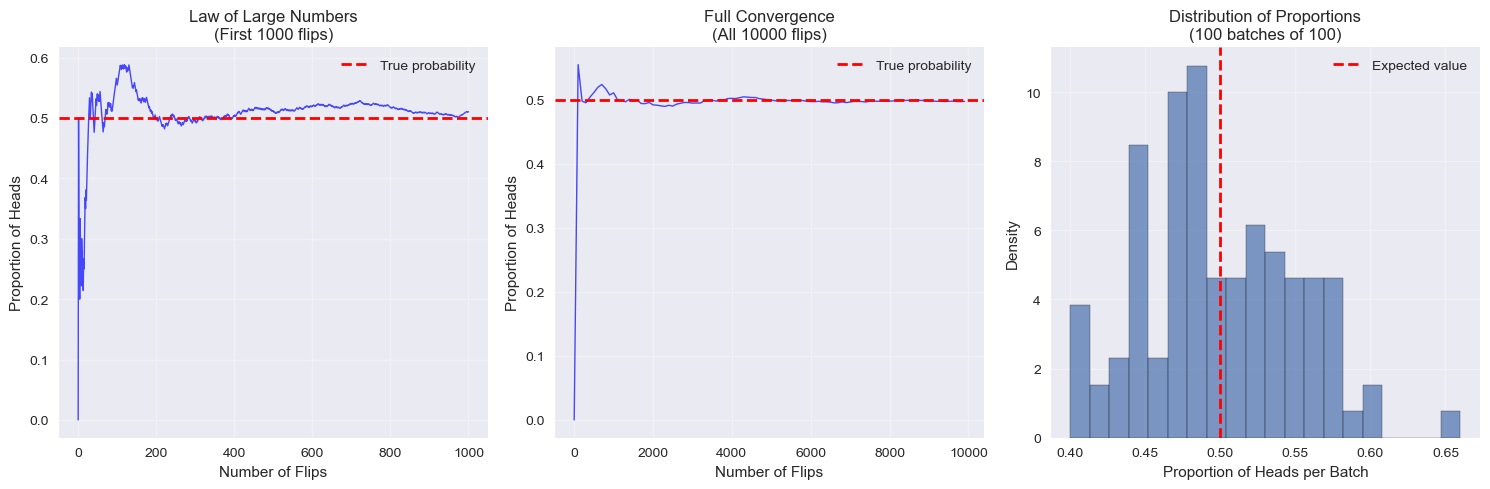


Simulation Results:
Final proportion of heads: 0.4987
Theoretical probability: 0.5000
Error: 0.0013
Standard deviation of batch proportions: 0.0511
Theoretical std (√(p(1-p)/n)): 0.0500


In [2]:
# Basic probability concepts
print("Fundamental Probability Rules:")
print("1. Sample Space (Ω): Set of all possible outcomes")
print("2. Event (A): Subset of sample space")
print("3. Probability (P): P(A) ∈ [0,1], P(Ω) = 1, P(∅) = 0")
print("")
print("Basic Rules:")
print("• Addition Rule: P(A ∪ B) = P(A) + P(B) - P(A ∩ B)")
print("• Multiplication Rule: P(A ∩ B) = P(A)P(B|A) = P(B)P(A|B)")
print("• Complement Rule: P(A') = 1 - P(A)")
print("• Total Probability: P(B) = Σᵢ P(B|Aᵢ)P(Aᵢ)")

# Simulate coin flips to demonstrate probability convergence
def simulate_coin_flips(n_flips):
    """Simulate coin flips and track probability convergence"""
    flips = np.random.choice([0, 1], size=n_flips)  # 0=Tails, 1=Heads
    cumulative_heads = np.cumsum(flips)
    trials = np.arange(1, n_flips + 1)
    probability_heads = cumulative_heads / trials
    return trials, probability_heads, flips

# Demonstrate Law of Large Numbers
n_flips = 10000
trials, prob_heads, flips = simulate_coin_flips(n_flips)

plt.figure(figsize=(15, 5))

# Plot 1: Probability convergence
plt.subplot(1, 3, 1)
plt.plot(trials[:1000], prob_heads[:1000], 'b-', alpha=0.7, linewidth=1)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='True probability')
plt.xlabel('Number of Flips')
plt.ylabel('Proportion of Heads')
plt.title('Law of Large Numbers\n(First 1000 flips)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Full convergence
plt.subplot(1, 3, 2)
# Sample every 100th point for cleaner visualization
sample_indices = np.arange(0, len(trials), 100)
plt.plot(trials[sample_indices], prob_heads[sample_indices], 'b-', alpha=0.7, linewidth=1)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='True probability')
plt.xlabel('Number of Flips')
plt.ylabel('Proportion of Heads')
plt.title(f'Full Convergence\n(All {n_flips} flips)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Distribution of outcomes in batches
plt.subplot(1, 3, 3)
batch_size = 100
n_batches = n_flips // batch_size
batch_proportions = []

for i in range(n_batches):
    start_idx = i * batch_size
    end_idx = (i + 1) * batch_size
    batch_heads = np.sum(flips[start_idx:end_idx])
    batch_proportions.append(batch_heads / batch_size)

plt.hist(batch_proportions, bins=20, alpha=0.7, edgecolor='black', density=True)
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Expected value')
plt.xlabel('Proportion of Heads per Batch')
plt.ylabel('Density')
plt.title(f'Distribution of Proportions\n({n_batches} batches of {batch_size})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSimulation Results:")
print(f"Final proportion of heads: {prob_heads[-1]:.4f}")
print(f"Theoretical probability: 0.5000")
print(f"Error: {abs(prob_heads[-1] - 0.5):.4f}")
print(f"Standard deviation of batch proportions: {np.std(batch_proportions):.4f}")
print(f"Theoretical std (√(p(1-p)/n)): {np.sqrt(0.5 * 0.5 / batch_size):.4f}")

### Set Theory and Probability

Set Theory and Probability:
P(A) = 0.698 (theoretical: 0.700)
P(B) = 0.801 (theoretical: 0.800)
P(A ∩ B) = 0.498 (theoretical: 0.500)
P(A ∪ B) = 1.000 (theoretical: 1.000)
P(A') = 0.302 (theoretical: 0.300)

Addition Rule Verification:
P(A) + P(B) - P(A ∩ B) = 1.000
P(A ∪ B) = 1.000
Difference: 0.000000


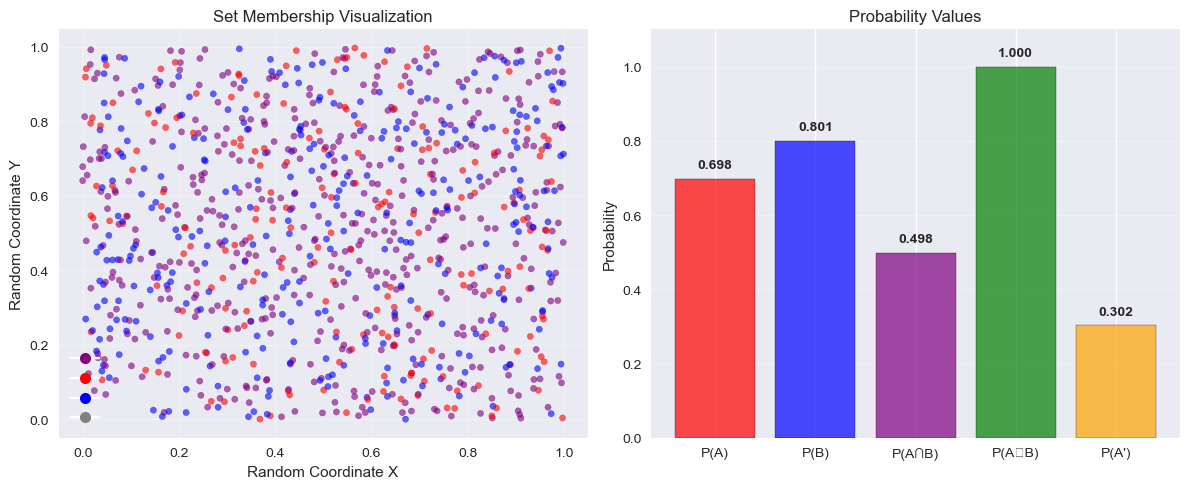

In [3]:
# Probability with sets - Venn diagram examples
def simulate_set_probabilities(n_samples=10000):
    """Simulate events A and B to demonstrate set operations"""
    # Define events with specific probabilities
    # A: Random number > 0.3 (P(A) = 0.7)
    # B: Random number < 0.8 (P(B) = 0.8)
    
    random_values = np.random.random(n_samples)
    
    A = random_values > 0.3  # Event A
    B = random_values < 0.8  # Event B
    
    # Calculate probabilities
    P_A = np.mean(A)
    P_B = np.mean(B)
    P_A_and_B = np.mean(A & B)  # Intersection
    P_A_or_B = np.mean(A | B)   # Union
    P_not_A = np.mean(~A)       # Complement
    
    return P_A, P_B, P_A_and_B, P_A_or_B, P_not_A, A, B

# Run simulation
P_A, P_B, P_A_and_B, P_A_or_B, P_not_A, A, B = simulate_set_probabilities()

print("Set Theory and Probability:")
print(f"P(A) = {P_A:.3f} (theoretical: 0.700)")
print(f"P(B) = {P_B:.3f} (theoretical: 0.800)")
print(f"P(A ∩ B) = {P_A_and_B:.3f} (theoretical: 0.500)")
print(f"P(A ∪ B) = {P_A_or_B:.3f} (theoretical: 1.000)")
print(f"P(A') = {P_not_A:.3f} (theoretical: 0.300)")

# Verify addition rule: P(A ∪ B) = P(A) + P(B) - P(A ∩ B)
addition_rule_result = P_A + P_B - P_A_and_B
print(f"\nAddition Rule Verification:")
print(f"P(A) + P(B) - P(A ∩ B) = {addition_rule_result:.3f}")
print(f"P(A ∪ B) = {P_A_or_B:.3f}")
print(f"Difference: {abs(addition_rule_result - P_A_or_B):.6f}")

# Visualize with a 2D scatter plot (simulating Venn diagram)
plt.figure(figsize=(12, 5))

# Plot 1: Scatter plot showing events
plt.subplot(1, 2, 1)
sample_size = 1000  # Use subset for visualization
random_vals = np.random.random(sample_size)
A_sample = random_vals > 0.3
B_sample = random_vals < 0.8

# Create 2D representation
x_coords = np.random.random(sample_size)
y_coords = np.random.random(sample_size)

# Color points based on set membership
colors = []
for i in range(sample_size):
    if A_sample[i] and B_sample[i]:
        colors.append('purple')  # A ∩ B
    elif A_sample[i]:
        colors.append('red')     # A only
    elif B_sample[i]:
        colors.append('blue')    # B only
    else:
        colors.append('gray')    # Neither

plt.scatter(x_coords, y_coords, c=colors, alpha=0.6, s=20)
plt.xlabel('Random Coordinate X')
plt.ylabel('Random Coordinate Y')
plt.title('Set Membership Visualization')
plt.legend(['A ∩ B', 'A only', 'B only', 'Neither'], 
          handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8) 
                  for c in ['purple', 'red', 'blue', 'gray']])
plt.grid(True, alpha=0.3)

# Plot 2: Probability bar chart
plt.subplot(1, 2, 2)
probabilities = [P_A, P_B, P_A_and_B, P_A_or_B, P_not_A]
labels = ['P(A)', 'P(B)', 'P(A∩B)', 'P(A∪B)', "P(A')"]
colors_bar = ['red', 'blue', 'purple', 'green', 'orange']

bars = plt.bar(labels, probabilities, color=colors_bar, alpha=0.7, edgecolor='black')
plt.ylabel('Probability')
plt.title('Probability Values')
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, prob in zip(bars, probabilities):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{prob:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Conditional Probability and Measure Theory

### Definition 2.1: Conditional Probability
For events A, B ∈ ℱ with P(B) > 0, the **conditional probability** is:
$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

This extends to **conditional probability measures**: For fixed B with P(B) > 0,
$$P(\cdot | B): \mathcal{F} \to [0,1], \quad P(A|B) = \frac{P(A \cap B)}{P(B)}$$

### Theorem 2.1: Bayes' Theorem (Measure-Theoretic Form)
Let (Ω, ℱ, P) be a probability space and {Bᵢ}ᵢ₌₁^∞ a countable partition of Ω with P(Bᵢ) > 0. For any A ∈ ℱ:

$$P(B_j | A) = \frac{P(A | B_j) P(B_j)}{\sum_{i=1}^{\infty} P(A | B_i) P(B_i)}$$

where the denominator is P(A) by the **law of total probability**.

### Definition 2.2: Conditional Expectation
Let X ∈ L¹(Ω, ℱ, P) and 𝒢 ⊆ ℱ a sub-σ-algebra. The **conditional expectation** E[X|𝒢] is the unique (a.s.) random variable Y that is:
1. 𝒢-measurable
2. ∫_G Y dP = ∫_G X dP for all G ∈ 𝒢

**Properties:**
- **Linearity**: E[aX + bY|𝒢] = aE[X|𝒢] + bE[Y|𝒢]
- **Tower Property**: E[E[X|𝒢₂]|𝒢₁] = E[X|𝒢₁] if 𝒢₁ ⊆ 𝒢₂
- **Taking Out What is Known**: E[YX|𝒢] = YE[X|𝒢] if Y is 𝒢-measurable
- **Independence**: E[X|𝒢] = E[X] if X ⊥ 𝒢

### Definition 2.3: Regular Conditional Probability
A **regular conditional probability** is a function P(·|·): ℱ × Ω → [0,1] such that:
1. For fixed ω, P(·|ω) is a probability measure on ℱ
2. For fixed A ∈ ℱ, P(A|·) is a version of P(A|𝒢)

**Existence:** Guaranteed for Polish spaces (complete separable metric spaces).

### Theorem 2.2: Radon-Nikodym Theorem for Conditional Densities
If μ ≪ ν are σ-finite measures on (Ω, ℱ), then there exists a measurable function f ≥ 0 such that:
$$\mu(A) = \int_A f \, d\nu \text{ for all } A \in \mathcal{F}$$

The function f = dμ/dν is called the **Radon-Nikodym derivative**.

**Application**: Conditional densities exist when the conditional distribution is absolutely continuous with respect to the conditioning measure.

In [4]:
# Conditional probability and Bayes' theorem
print("Conditional Probability:")
print("P(A|B) = P(A ∩ B) / P(B)")
print("")
print("Bayes' Theorem:")
print("P(A|B) = P(B|A) × P(A) / P(B)")
print("")
print("where:")
print("• P(A|B): Posterior probability")
print("• P(B|A): Likelihood")
print("• P(A): Prior probability")
print("• P(B): Marginal probability (evidence)")

# Medical diagnosis example (classic Bayes' theorem application)
def medical_diagnosis_example():
    """
    Medical test example:
    - Disease prevalence: 1% of population
    - Test sensitivity: 90% (correct positive rate)
    - Test specificity: 95% (correct negative rate)
    
    Question: If test is positive, what's probability of having disease?
    """
    
    # Define probabilities
    P_disease = 0.01        # Prior: disease prevalence
    P_no_disease = 0.99     # Prior: no disease
    P_pos_given_disease = 0.90      # Likelihood: P(positive test | disease)
    P_pos_given_no_disease = 0.05   # P(positive test | no disease) = 1 - specificity
    
    # Calculate marginal probability P(positive test)
    P_positive = (P_pos_given_disease * P_disease + 
                  P_pos_given_no_disease * P_no_disease)
    
    # Apply Bayes' theorem
    P_disease_given_positive = (P_pos_given_disease * P_disease) / P_positive
    
    return {
        'prior': P_disease,
        'likelihood': P_pos_given_disease,
        'evidence': P_positive,
        'posterior': P_disease_given_positive
    }

# Calculate medical diagnosis
diagnosis = medical_diagnosis_example()

print(f"\nMedical Diagnosis Example:")
print(f"Prior P(Disease) = {diagnosis['prior']:.3f}")
print(f"Likelihood P(Positive|Disease) = {diagnosis['likelihood']:.3f}")
print(f"Evidence P(Positive) = {diagnosis['evidence']:.3f}")
print(f"Posterior P(Disease|Positive) = {diagnosis['posterior']:.3f}")
print(f"")
print(f"Interpretation: Even with a positive test, there's only a {diagnosis['posterior']:.1%} chance")
print(f"of actually having the disease! This shows the importance of base rates.")

# Simulate the medical test scenario
def simulate_medical_test(n_people=100000):
    """Simulate medical testing scenario"""
    # Generate population
    has_disease = np.random.random(n_people) < 0.01  # 1% have disease
    
    # Generate test results
    test_results = np.zeros(n_people, dtype=bool)
    
    # For people with disease: 90% test positive
    disease_indices = np.where(has_disease)[0]
    test_results[disease_indices] = np.random.random(len(disease_indices)) < 0.90
    
    # For people without disease: 5% test positive (false positive)
    no_disease_indices = np.where(~has_disease)[0]
    test_results[no_disease_indices] = np.random.random(len(no_disease_indices)) < 0.05
    
    return has_disease, test_results

# Run simulation
has_disease, test_results = simulate_medical_test()

# Calculate confusion matrix
true_positives = np.sum(has_disease & test_results)
false_positives = np.sum(~has_disease & test_results)
true_negatives = np.sum(~has_disease & ~test_results)
false_negatives = np.sum(has_disease & ~test_results)

# Calculate rates
sensitivity = true_positives / np.sum(has_disease)  # True positive rate
specificity = true_negatives / np.sum(~has_disease)  # True negative rate
ppv = true_positives / np.sum(test_results)  # Positive predictive value
npv = true_negatives / np.sum(~test_results)  # Negative predictive value

print(f"\nSimulation Results (n={len(has_disease):,}):")
print(f"Sensitivity (True Positive Rate): {sensitivity:.3f}")
print(f"Specificity (True Negative Rate): {specificity:.3f}")
print(f"Positive Predictive Value: {ppv:.3f}")
print(f"Negative Predictive Value: {npv:.3f}")
print(f"")
print(f"Theoretical PPV: {diagnosis['posterior']:.3f}")
print(f"Simulated PPV: {ppv:.3f}")
print(f"Difference: {abs(diagnosis['posterior'] - ppv):.4f}")

Conditional Probability:
P(A|B) = P(A ∩ B) / P(B)

Bayes' Theorem:
P(A|B) = P(B|A) × P(A) / P(B)

where:
• P(A|B): Posterior probability
• P(B|A): Likelihood
• P(A): Prior probability
• P(B): Marginal probability (evidence)

Medical Diagnosis Example:
Prior P(Disease) = 0.010
Likelihood P(Positive|Disease) = 0.900
Evidence P(Positive) = 0.059
Posterior P(Disease|Positive) = 0.154

Interpretation: Even with a positive test, there's only a 15.4% chance
of actually having the disease! This shows the importance of base rates.

Simulation Results (n=100,000):
Sensitivity (True Positive Rate): 0.895
Specificity (True Negative Rate): 0.951
Positive Predictive Value: 0.155
Negative Predictive Value: 0.999

Theoretical PPV: 0.154
Simulated PPV: 0.155
Difference: 0.0016


### Visualizing Bayes' Theorem

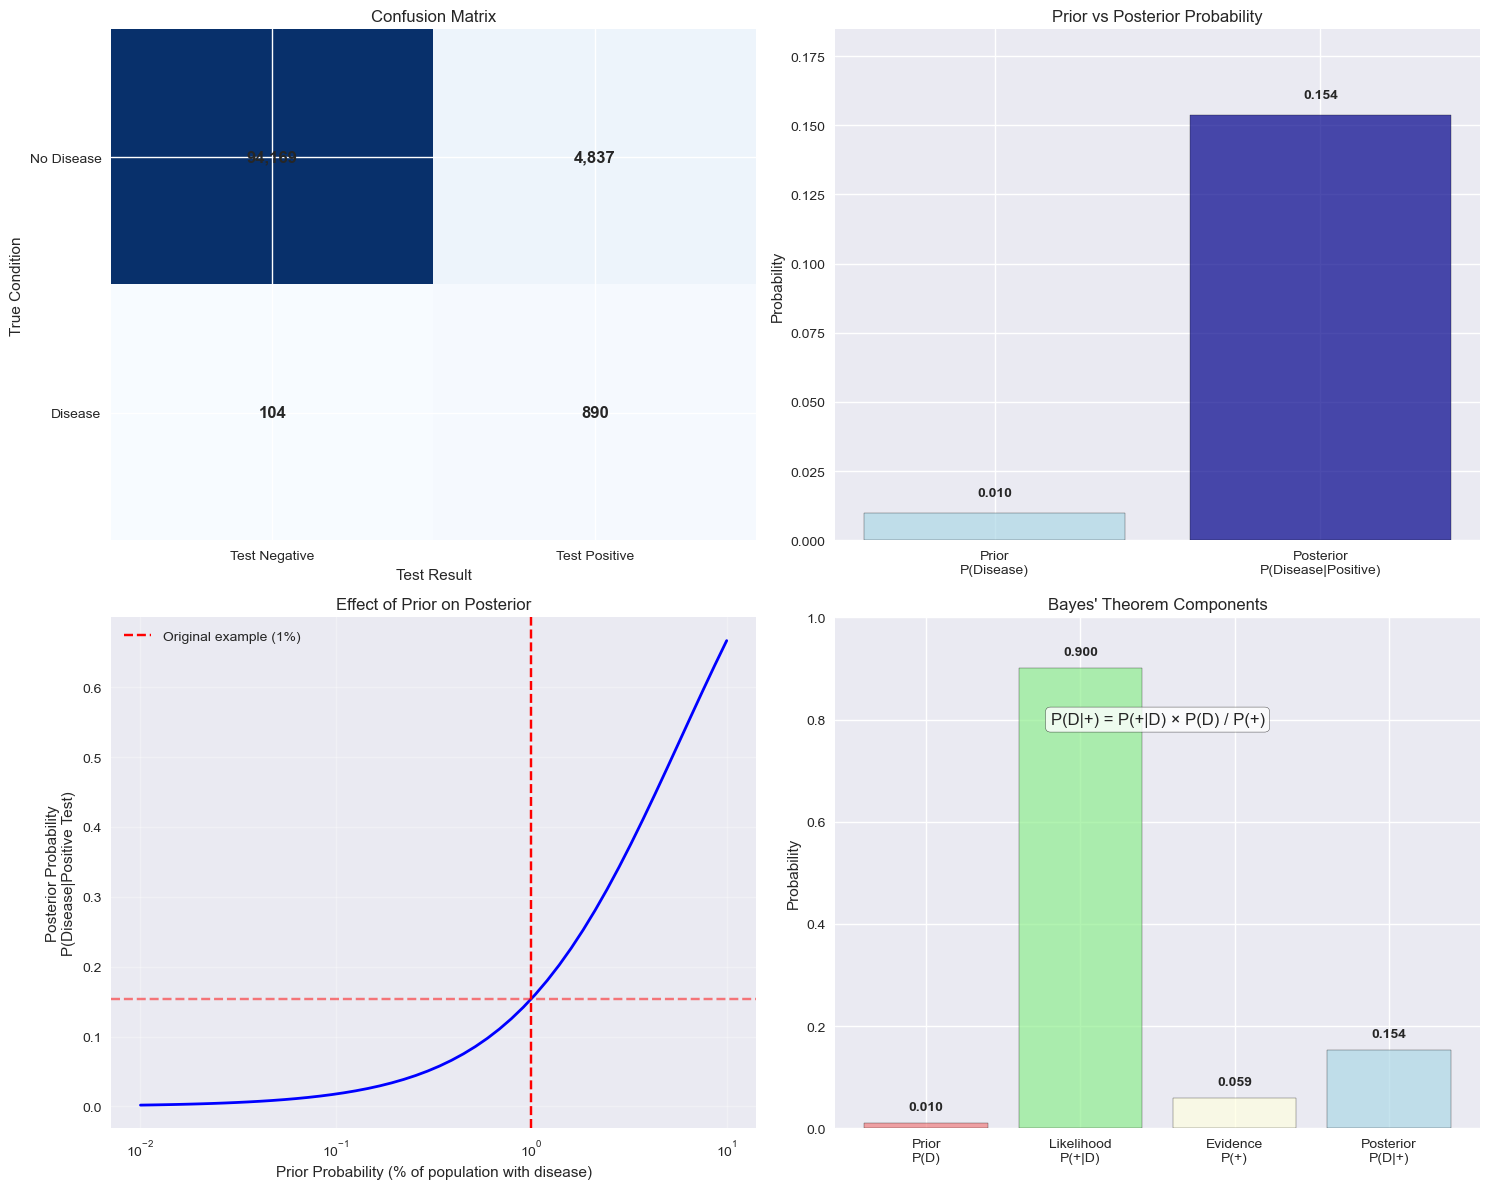


Key Insights:
• Base rate matters: Low disease prevalence means most positives are false
• Perfect tests don't exist: Sensitivity and specificity trade-offs
• Bayes' theorem updates beliefs with evidence
• Prior probability significantly affects posterior


In [5]:
# Visualize Bayes' theorem and its components
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
confusion_matrix_data = np.array([[true_negatives, false_positives],
                                  [false_negatives, true_positives]])

im = ax1.imshow(confusion_matrix_data, cmap='Blues', aspect='auto')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Test Negative', 'Test Positive'])
ax1.set_yticklabels(['No Disease', 'Disease'])
ax1.set_xlabel('Test Result')
ax1.set_ylabel('True Condition')
ax1.set_title('Confusion Matrix')

# Add text annotations
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{confusion_matrix_data[i, j]:,}', 
                ha='center', va='center', fontsize=12, fontweight='bold')

# Plot 2: Prior vs Posterior
ax2 = axes[0, 1]
categories = ['Prior\nP(Disease)', 'Posterior\nP(Disease|Positive)']
probabilities = [diagnosis['prior'], diagnosis['posterior']]
colors = ['lightblue', 'darkblue']

bars = ax2.bar(categories, probabilities, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Probability')
ax2.set_title('Prior vs Posterior Probability')
ax2.set_ylim(0, max(probabilities) * 1.2)

for bar, prob in zip(bars, probabilities):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{prob:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Effect of prior probability
ax3 = axes[1, 0]
prior_range = np.logspace(-4, -1, 50)  # From 0.01% to 10%
posterior_range = []

sensitivity = 0.90
specificity = 0.95
false_positive_rate = 1 - specificity

for prior in prior_range:
    evidence = sensitivity * prior + false_positive_rate * (1 - prior)
    posterior = (sensitivity * prior) / evidence
    posterior_range.append(posterior)

ax3.semilogx(prior_range * 100, posterior_range, 'b-', linewidth=2)
ax3.axvline(x=1, color='red', linestyle='--', label='Original example (1%)')
ax3.axhline(y=diagnosis['posterior'], color='red', linestyle='--', alpha=0.5)
ax3.set_xlabel('Prior Probability (% of population with disease)')
ax3.set_ylabel('Posterior Probability\nP(Disease|Positive Test)')
ax3.set_title('Effect of Prior on Posterior')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Bayes' theorem components
ax4 = axes[1, 1]
components = ['Prior\nP(D)', 'Likelihood\nP(+|D)', 'Evidence\nP(+)', 'Posterior\nP(D|+)']
values = [diagnosis['prior'], diagnosis['likelihood'], diagnosis['evidence'], diagnosis['posterior']]
colors = ['lightcoral', 'lightgreen', 'lightyellow', 'lightblue']

bars = ax4.bar(components, values, color=colors, alpha=0.7, edgecolor='black')
ax4.set_ylabel('Probability')
ax4.set_title('Bayes\' Theorem Components')
ax4.set_ylim(0, 1)

for bar, val in zip(bars, values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# Add Bayes' formula as text
formula_text = "P(D|+) = P(+|D) × P(D) / P(+)"
ax4.text(0.5, 0.8, formula_text, transform=ax4.transAxes, 
         ha='center', va='center', fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nKey Insights:")
print(f"• Base rate matters: Low disease prevalence means most positives are false")
print(f"• Perfect tests don't exist: Sensitivity and specificity trade-offs")
print(f"• Bayes' theorem updates beliefs with evidence")
print(f"• Prior probability significantly affects posterior")

### ML Application: Naive Bayes Classifier

In [6]:
# Naive Bayes classifier implementation and demonstration
class SimpleNaiveBayes:
    def __init__(self):
        self.class_priors = {}
        self.feature_stats = {}  # Mean and std for each feature per class
        self.classes = None
    
    def fit(self, X, y):
        """Train the Naive Bayes classifier"""
        self.classes = np.unique(y)
        n_samples = len(y)
        
        for class_label in self.classes:
            # Calculate class prior P(class)
            class_mask = (y == class_label)
            self.class_priors[class_label] = np.sum(class_mask) / n_samples
            
            # Calculate feature statistics for this class
            class_data = X[class_mask]
            self.feature_stats[class_label] = {
                'mean': np.mean(class_data, axis=0),
                'std': np.std(class_data, axis=0) + 1e-6  # Add small value to avoid division by zero
            }
    
    def _gaussian_likelihood(self, x, mean, std):
        """Calculate Gaussian likelihood P(x|class)"""
        exponent = -0.5 * ((x - mean) / std) ** 2
        return (1 / (std * np.sqrt(2 * np.pi))) * np.exp(exponent)
    
    def predict_proba(self, X):
        """Predict class probabilities using Bayes' theorem"""
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        probabilities = np.zeros((n_samples, n_classes))
        
        for i, class_label in enumerate(self.classes):
            # Prior probability
            prior = self.class_priors[class_label]
            
            # Likelihood (assuming independence - "naive" assumption)
            mean = self.feature_stats[class_label]['mean']
            std = self.feature_stats[class_label]['std']
            
            # Calculate likelihood for each feature and multiply (log space would be more stable)
            likelihood = np.prod(
                self.._gaussian_likelihood(X, mean, std), axis=1
            )
            
            # Posterior ∝ Prior × Likelihood (unnormalized)
            probabilities[:, i] = prior * likelihood
        
        # Normalize to get actual probabilities
        row_sums = probabilities.sum(axis=1, keepdims=True)
        probabilities = probabilities / (row_sums + 1e-10)
        
        return probabilities
    
    def predict(self, X):
        """Predict class labels"""
        probabilities = self.predict_proba(X)
        return self.classes[np.argmax(probabilities, axis=1)]

# Load iris dataset for demonstration
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Iris Dataset:")
print(f"Features: {feature_names}")
print(f"Classes: {target_names}")
print(f"Data shape: {X_iris.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Train our implementation
nb_custom = SimpleNaiveBayes()
nb_custom.fit(X_train, y_train)

# Train sklearn implementation for comparison
nb_sklearn = GaussianNB()
nb_sklearn.fit(X_train, y_train)

# Make predictions
y_pred_custom = nb_custom.predict(X_test)
y_pred_sklearn = nb_sklearn.predict(X_test)
y_proba_custom = nb_custom.predict_proba(X_test)
y_proba_sklearn = nb_sklearn.predict_proba(X_test)

# Calculate accuracies
accuracy_custom = np.mean(y_pred_custom == y_test)
accuracy_sklearn = np.mean(y_pred_sklearn == y_test)

print(f"\nResults:")
print(f"Custom implementation accuracy: {accuracy_custom:.3f}")
print(f"Sklearn implementation accuracy: {accuracy_sklearn:.3f}")

# Show class priors and feature statistics
print(f"\nClass Priors (P(class)):")
for class_label in nb_custom.classes:
    prior = nb_custom.class_priors[class_label]
    class_name = target_names[class_label]
    print(f"  {class_name}: {prior:.3f}")

print(f"\nFeature Statistics by Class:")
for class_label in nb_custom.classes:
    class_name = target_names[class_label]
    stats = nb_custom.feature_stats[class_label]
    print(f"\n{class_name}:")
    for i, feature_name in enumerate(feature_names):
        mean = stats['mean'][i]
        std = stats['std'][i]
        print(f"  {feature_name}: μ={mean:.2f}, σ={std:.2f}")

SyntaxError: invalid syntax (3231934331.py, line 46)

# Assistant
The error is occurring because the code snippet you provided is incomplete. It appears to be a part of a class implementation for a Naive Bayes classifier, but the beginning of the class definition and some methods are missing.

The error specifically points to line 46, which is likely where the code starts in your file. The issue is that the code begins with a line that appears to be in the middle of a method:


In [12]:
es = probabilities / (row_sums + 1e-10)
        
        return probabilities

IndentationError: unexpected indent (3317389080.py, line 3)


This is not valid Python syntax when it appears at the beginning of a file or code block.

Would you like me to provide a corrected version of the code?

## 3. Advanced Theory of Random Variables and Distributions

### Definition 3.1: Lebesgue-Stieltjes Integration
For a random variable X with distribution function F, the **expectation** (when it exists) is defined as:
$$E[X] = \int_{-\infty}^{\infty} x \, dF(x) = \int_{\Omega} X(\omega) \, dP(\omega)$$

For any measurable function g: ℝ → ℝ:
$$E[g(X)] = \int_{-\infty}^{\infty} g(x) \, dF(x)$$

### Theorem 3.1: Fubini-Tonelli for Probability
Let (X,Y) be a random vector on (Ω₁ × Ω₂, ℱ₁ ⊗ ℱ₂, P₁ ⊗ P₂). If g: ℝ² → ℝ is measurable:

1. **Tonelli**: If g ≥ 0, then:
   $$\int g(x,y) \, d(P_1 \otimes P_2) = \int \left(\int g(x,y) \, dP_2(y)\right) dP_1(x)$$

2. **Fubini**: If ∫|g|d(P₁ ⊗ P₂) < ∞, then the integrals can be computed iteratively.

### Definition 3.2: Characteristic Functions
The **characteristic function** of a random variable X is:
$$\phi_X(t) = E[e^{itX}] = \int_{-\infty}^{\infty} e^{itx} \, dF(x), \quad t \in \mathbb{R}$$

**Properties:**
- **Uniqueness**: φₓ determines the distribution of X uniquely
- **Inversion Formula**: For continuous F,
  $$F(b) - F(a) = \lim_{T \to \infty} \frac{1}{2\pi} \int_{-T}^{T} \frac{e^{-ita} - e^{-itb}}{it} \phi_X(t) \, dt$$
- **Independence**: If X ⊥ Y, then φₓ₊ᵧ(t) = φₓ(t)φᵧ(t)

### Theorem 3.2: Lévy Continuity Theorem
Let {Xₙ} be random variables with characteristic functions {φₙ}. Then:
$$X_n \xrightarrow{d} X \iff \phi_n(t) \to \phi(t) \text{ pointwise}$$
where φ is continuous at 0.

### Definition 3.3: Exponential Families
A family of probability measures {Pθ : θ ∈ Θ} has **natural exponential family** form if:
$$\frac{dP_\theta}{d\mu}(x) = \exp\left[\sum_{i=1}^{k} \theta_i T_i(x) - A(\theta)\right]$$

where:
- T(x) = (T₁(x), ..., Tₖ(x)) is the **sufficient statistic**
- A(θ) = log ∫ exp[Σᵢ θᵢTᵢ(x)] dμ(x) is the **log-partition function**
- μ is a σ-finite reference measure

**Properties:**
- **Natural Parameter Space**: Θ = {θ : A(θ) < ∞}
- **Moment Generating Property**: ∇A(θ) = Eθ[T(X)]
- **Variance Structure**: ∇²A(θ) = Varθ(T(X))

### Theorem 3.3: Cramér's Theorem (Large Deviations)
Let {Xₙ} be i.i.d. with moment generating function M(t) = E[e^{tX₁}]. Define the rate function:
$$I(x) = \sup_{t \in \mathbb{R}} [tx - \log M(t)]$$

Then for any closed set F:
$$\limsup_{n \to \infty} \frac{1}{n} \log P\left(\frac{S_n}{n} \in F\right) \leq -\inf_{x \in F} I(x)$$

where Sₙ = X₁ + ... + Xₙ. This quantifies the exponential decay rate of tail probabilities.

Random Variables:
• Discrete: Takes countable values (e.g., coin flips, counts)
• Continuous: Takes uncountable values (e.g., height, weight)

Key Functions:
• PMF (Discrete): P(X = x)
• PDF (Continuous): f(x), where P(a ≤ X ≤ b) = ∫ᵃᵇ f(x)dx
• CDF: F(x) = P(X ≤ x)


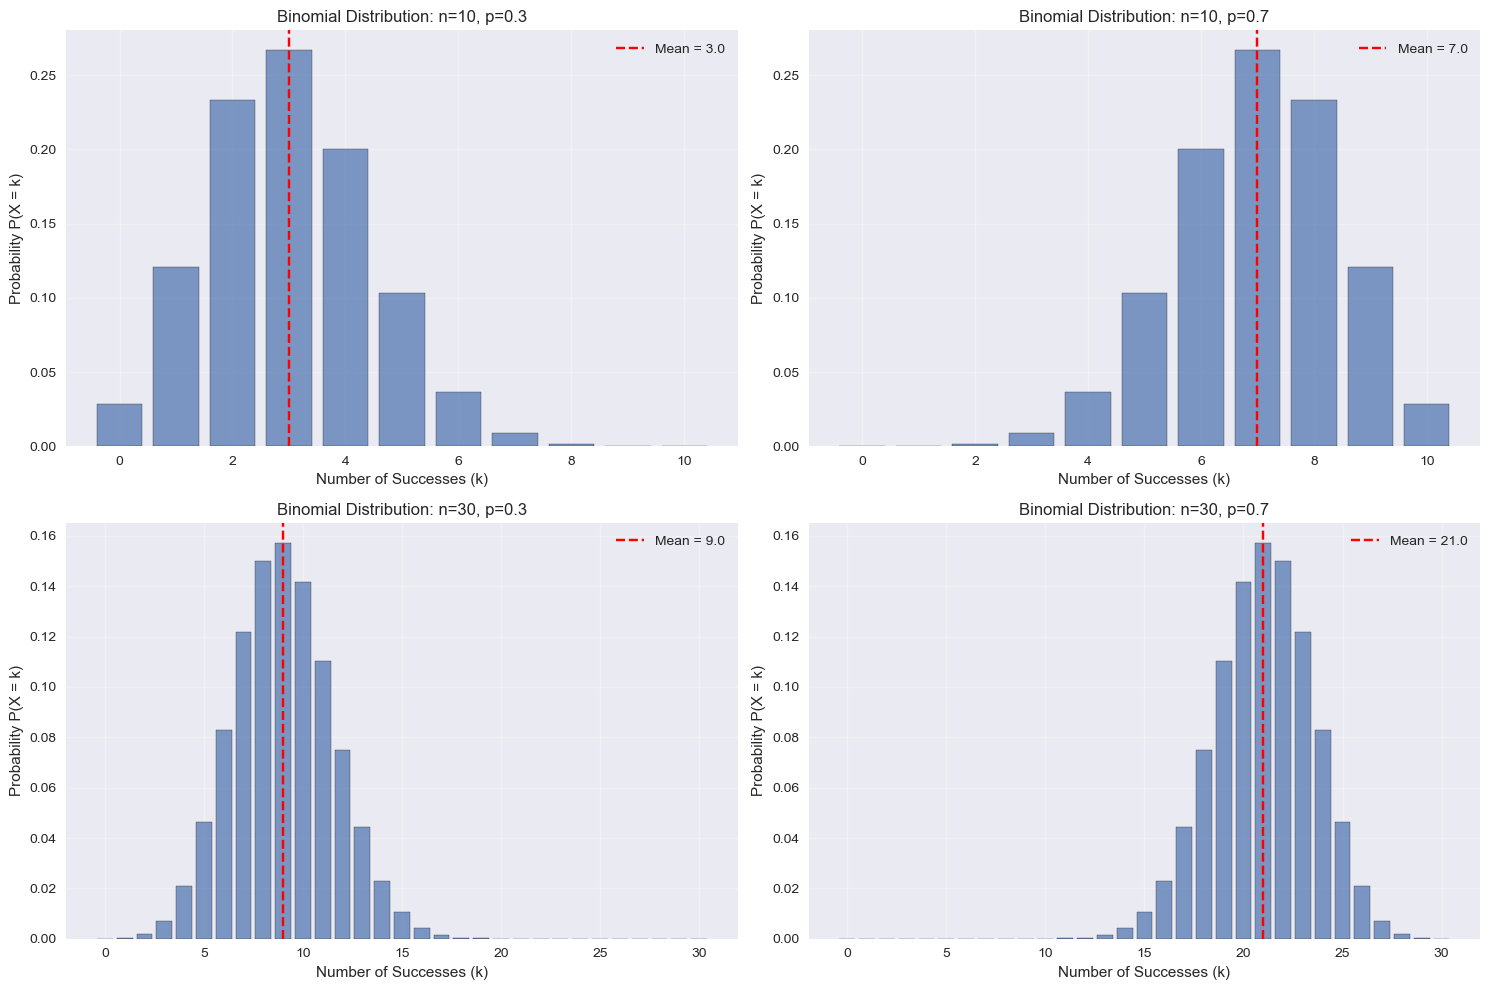

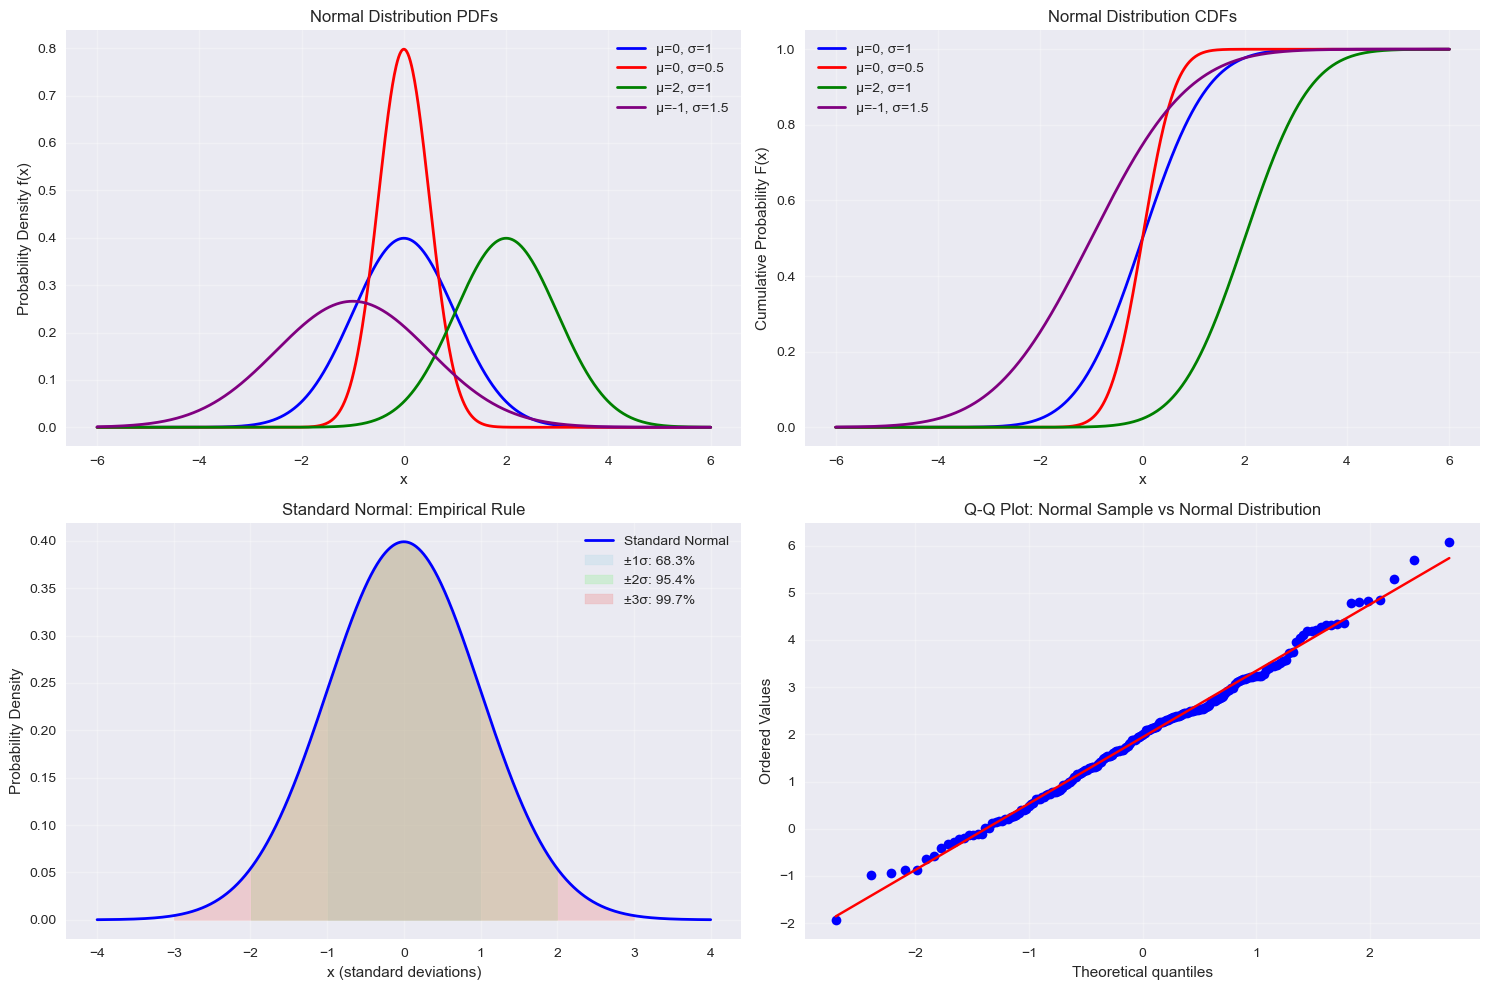


Key Distribution Properties:
• Normal distribution: Bell-shaped, symmetric, defined by μ and σ
• Central Limit Theorem: Sample means approach normal distribution
• Empirical Rule: ~68% within 1σ, ~95% within 2σ, ~99.7% within 3σ
• Many real-world phenomena follow normal distribution


In [7]:
# Random variables and probability distributions
print("Random Variables:")
print("• Discrete: Takes countable values (e.g., coin flips, counts)")
print("• Continuous: Takes uncountable values (e.g., height, weight)")
print("")
print("Key Functions:")
print("• PMF (Discrete): P(X = x)")
print("• PDF (Continuous): f(x), where P(a ≤ X ≤ b) = ∫ᵃᵇ f(x)dx")
print("• CDF: F(x) = P(X ≤ x)")

# Demonstrate discrete distribution: Binomial
def plot_binomial_distribution():
    """Plot binomial distribution with different parameters"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Different parameter combinations
    params = [(10, 0.3), (10, 0.7), (30, 0.3), (30, 0.7)]
    titles = [f'n={n}, p={p}' for n, p in params]
    
    for i, ((n, p), title) in enumerate(zip(params, titles)):
        ax = axes[i//2, i%2]
        
        # Generate x values
        x = np.arange(0, n+1)
        
        # Calculate PMF
        pmf = stats.binom.pmf(x, n, p)
        
        # Plot
        ax.bar(x, pmf, alpha=0.7, edgecolor='black')
        ax.set_xlabel('Number of Successes (k)')
        ax.set_ylabel('Probability P(X = k)')
        ax.set_title(f'Binomial Distribution: {title}')
        ax.grid(True, alpha=0.3)
        
        # Add mean and variance
        mean = n * p
        var = n * p * (1 - p)
        ax.axvline(x=mean, color='red', linestyle='--', label=f'Mean = {mean:.1f}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_binomial_distribution()

# Demonstrate continuous distribution: Normal (Gaussian)
def plot_normal_distribution():
    """Plot normal distribution with different parameters"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    x = np.linspace(-6, 6, 1000)
    
    # Different parameter combinations
    params = [(0, 1), (0, 0.5), (2, 1), (-1, 1.5)]
    colors = ['blue', 'red', 'green', 'purple']
    
    # Plot 1: Different distributions
    ax1 = axes[0, 0]
    for (mu, sigma), color in zip(params, colors):
        pdf = stats.norm.pdf(x, mu, sigma)
        ax1.plot(x, pdf, color=color, linewidth=2, label=f'μ={mu}, σ={sigma}')
    
    ax1.set_xlabel('x')
    ax1.set_ylabel('Probability Density f(x)')
    ax1.set_title('Normal Distribution PDFs')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: CDF
    ax2 = axes[0, 1]
    for (mu, sigma), color in zip(params, colors):
        cdf = stats.norm.cdf(x, mu, sigma)
        ax2.plot(x, cdf, color=color, linewidth=2, label=f'μ={mu}, σ={sigma}')
    
    ax2.set_xlabel('x')
    ax2.set_ylabel('Cumulative Probability F(x)')
    ax2.set_title('Normal Distribution CDFs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Standard normal with areas
    ax3 = axes[1, 0]
    x_std = np.linspace(-4, 4, 1000)
    pdf_std = stats.norm.pdf(x_std, 0, 1)
    ax3.plot(x_std, pdf_std, 'b-', linewidth=2, label='Standard Normal')
    
    # Shade areas for different standard deviations
    areas = [1, 2, 3]
    colors_shade = ['lightblue', 'lightgreen', 'lightcoral']
    
    for std_dev, color in zip(areas, colors_shade):
        x_fill = x_std[(x_std >= -std_dev) & (x_std <= std_dev)]
        y_fill = stats.norm.pdf(x_fill, 0, 1)
        ax3.fill_between(x_fill, y_fill, alpha=0.3, color=color, 
                        label=f'±{std_dev}σ: {stats.norm.cdf(std_dev) - stats.norm.cdf(-std_dev):.1%}')
    
    ax3.set_xlabel('x (standard deviations)')
    ax3.set_ylabel('Probability Density')
    ax3.set_title('Standard Normal: Empirical Rule')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Q-Q plot demonstration
    ax4 = axes[1, 1]
    
    # Generate sample data
    np.random.seed(42)
    sample_normal = np.random.normal(2, 1.5, 200)
    sample_uniform = np.random.uniform(0, 5, 200)
    
    # Q-Q plot against normal distribution
    stats.probplot(sample_normal, dist="norm", plot=ax4)
    ax4.set_title('Q-Q Plot: Normal Sample vs Normal Distribution')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_normal_distribution()

print(f"\nKey Distribution Properties:")
print(f"• Normal distribution: Bell-shaped, symmetric, defined by μ and σ")
print(f"• Central Limit Theorem: Sample means approach normal distribution")
print(f"• Empirical Rule: ~68% within 1σ, ~95% within 2σ, ~99.7% within 3σ")
print(f"• Many real-world phenomena follow normal distribution")

### Expected Value, Variance, and Moments

Statistical Moments:
• 1st moment: Expected Value E[X] = μ
• 2nd moment: Variance Var(X) = E[(X-μ)²] = σ²
• 3rd moment: Skewness (asymmetry)
• 4th moment: Kurtosis (tail behavior)

Moments Comparison:
  Distribution  Mean (μ)  Variance (σ²)  Std Dev (σ)  Skewness  Kurtosis
0       Normal    -0.002          1.007        1.003     0.002     0.026
1  Exponential     1.027          1.051        1.025     1.997     5.819
2      Uniform    -0.013          1.318        1.148     0.016    -1.191
3      Bimodal    -0.008          4.236        2.058     0.002    -1.765


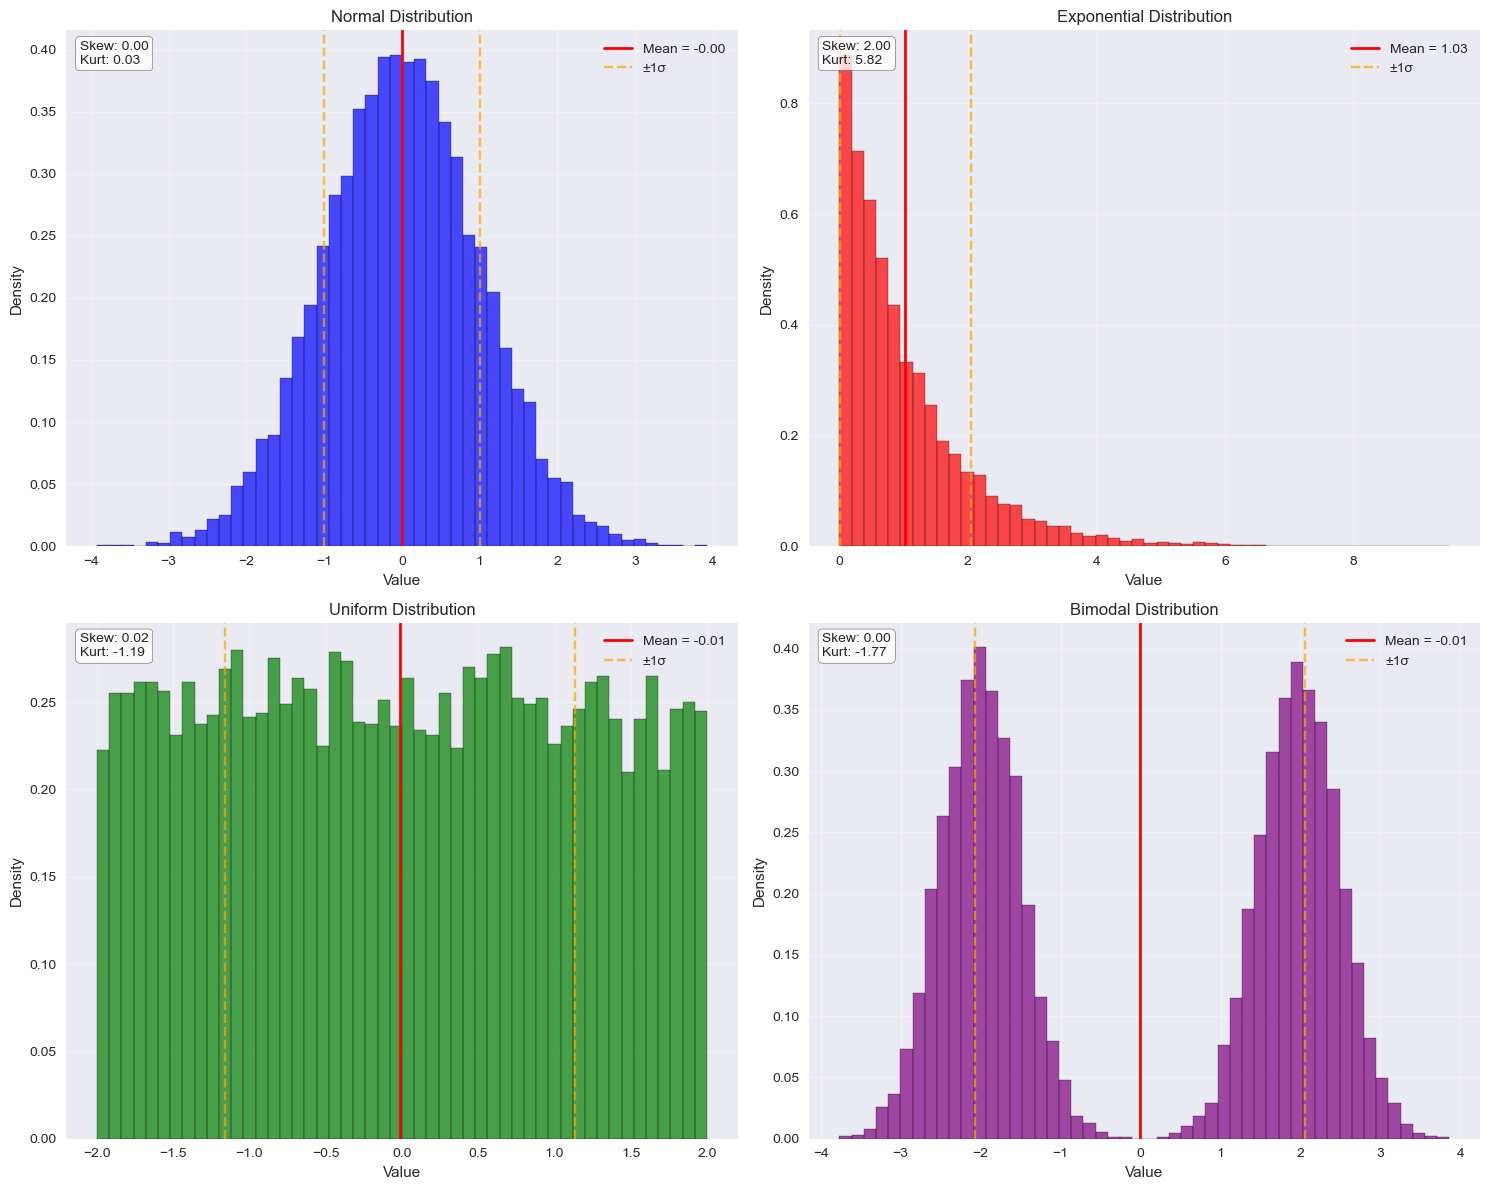

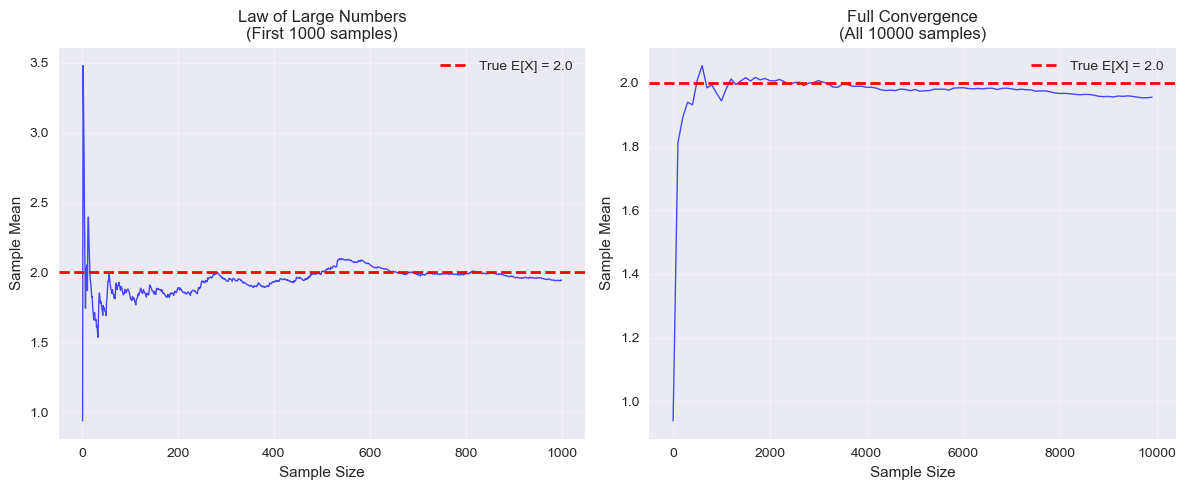


Law of Large Numbers Demonstration:
True expected value: 2.000
Sample mean (n=100): 1.829
Sample mean (n=1000): 1.945
Sample mean (n=10000): 1.955
Final error: 0.0450

Interpretation of Moments:
• Mean: Central tendency, 'center of mass'
• Variance/Std Dev: Spread around the mean
• Skewness: 0=symmetric, >0=right tail, <0=left tail
• Kurtosis: 0=normal tails, >0=heavy tails, <0=light tails


In [8]:
# Expected value, variance, and higher moments
print("Statistical Moments:")
print("• 1st moment: Expected Value E[X] = μ")
print("• 2nd moment: Variance Var(X) = E[(X-μ)²] = σ²")
print("• 3rd moment: Skewness (asymmetry)")
print("• 4th moment: Kurtosis (tail behavior)")

def demonstrate_moments():
    """Demonstrate different statistical moments with examples"""
    
    # Generate different types of distributions
    np.random.seed(42)
    n_samples = 10000
    
    # Different distributions to compare
    distributions = {
        'Normal': np.random.normal(0, 1, n_samples),
        'Exponential': np.random.exponential(1, n_samples),
        'Uniform': np.random.uniform(-2, 2, n_samples),
        'Bimodal': np.concatenate([
            np.random.normal(-2, 0.5, n_samples//2),
            np.random.normal(2, 0.5, n_samples//2)
        ])
    }
    
    # Calculate moments
    moments_data = []
    
    for name, data in distributions.items():
        mean = np.mean(data)
        variance = np.var(data)
        std = np.std(data)
        skewness = stats.skew(data)
        kurtosis = stats.kurtosis(data)
        
        moments_data.append({
            'Distribution': name,
            'Mean (μ)': mean,
            'Variance (σ²)': variance,
            'Std Dev (σ)': std,
            'Skewness': skewness,
            'Kurtosis': kurtosis
        })
    
    # Create DataFrame for nice display
    df_moments = pd.DataFrame(moments_data)
    print(f"\nMoments Comparison:")
    print(df_moments.round(3))
    
    # Visualize distributions and their properties
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    colors = ['blue', 'red', 'green', 'purple']
    
    for i, (name, data) in enumerate(distributions.items()):
        ax = axes[i//2, i%2]
        
        # Histogram
        ax.hist(data, bins=50, density=True, alpha=0.7, color=colors[i], edgecolor='black')
        
        # Add vertical lines for mean and std
        mean = np.mean(data)
        std = np.std(data)
        
        ax.axvline(mean, color='red', linestyle='-', linewidth=2, label=f'Mean = {mean:.2f}')
        ax.axvline(mean - std, color='orange', linestyle='--', alpha=0.7, label=f'±1σ')
        ax.axvline(mean + std, color='orange', linestyle='--', alpha=0.7)
        
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.set_title(f'{name} Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add text with moments
        skew = stats.skew(data)
        kurt = stats.kurtosis(data)
        text = f'Skew: {skew:.2f}\nKurt: {kurt:.2f}'
        ax.text(0.02, 0.98, text, transform=ax.transAxes, 
                verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return distributions

distributions = demonstrate_moments()

# Demonstrate Law of Large Numbers for expected value
def demonstrate_law_of_large_numbers():
    """Show convergence of sample mean to expected value"""
    
    # Use exponential distribution (clear theoretical expectation)
    scale = 2.0  # E[X] = scale = 2.0
    
    # Generate large sample
    np.random.seed(42)
    n_max = 10000
    samples = np.random.exponential(scale, n_max)
    
    # Calculate running mean
    sample_sizes = np.arange(1, n_max + 1)
    running_means = np.cumsum(samples) / sample_sizes
    
    # Plot convergence
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(sample_sizes[:1000], running_means[:1000], 'b-', alpha=0.7, linewidth=1)
    plt.axhline(y=scale, color='red', linestyle='--', linewidth=2, label=f'True E[X] = {scale}')
    plt.xlabel('Sample Size')
    plt.ylabel('Sample Mean')
    plt.title('Law of Large Numbers\n(First 1000 samples)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    # Sample every 100th point for full range
    sample_indices = np.arange(0, len(sample_sizes), 100)
    plt.plot(sample_sizes[sample_indices], running_means[sample_indices], 'b-', alpha=0.7, linewidth=1)
    plt.axhline(y=scale, color='red', linestyle='--', linewidth=2, label=f'True E[X] = {scale}')
    plt.xlabel('Sample Size')
    plt.ylabel('Sample Mean')
    plt.title(f'Full Convergence\n(All {n_max} samples)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nLaw of Large Numbers Demonstration:")
    print(f"True expected value: {scale:.3f}")
    print(f"Sample mean (n=100): {running_means[99]:.3f}")
    print(f"Sample mean (n=1000): {running_means[999]:.3f}")
    print(f"Sample mean (n=10000): {running_means[-1]:.3f}")
    print(f"Final error: {abs(running_means[-1] - scale):.4f}")

demonstrate_law_of_large_numbers()

print(f"\nInterpretation of Moments:")
print(f"• Mean: Central tendency, 'center of mass'")
print(f"• Variance/Std Dev: Spread around the mean")
print(f"• Skewness: 0=symmetric, >0=right tail, <0=left tail")
print(f"• Kurtosis: 0=normal tails, >0=heavy tails, <0=light tails")

## 4. Common Distributions in Machine Learning

Different probability distributions model different types of uncertainty and are used in various ML algorithms.

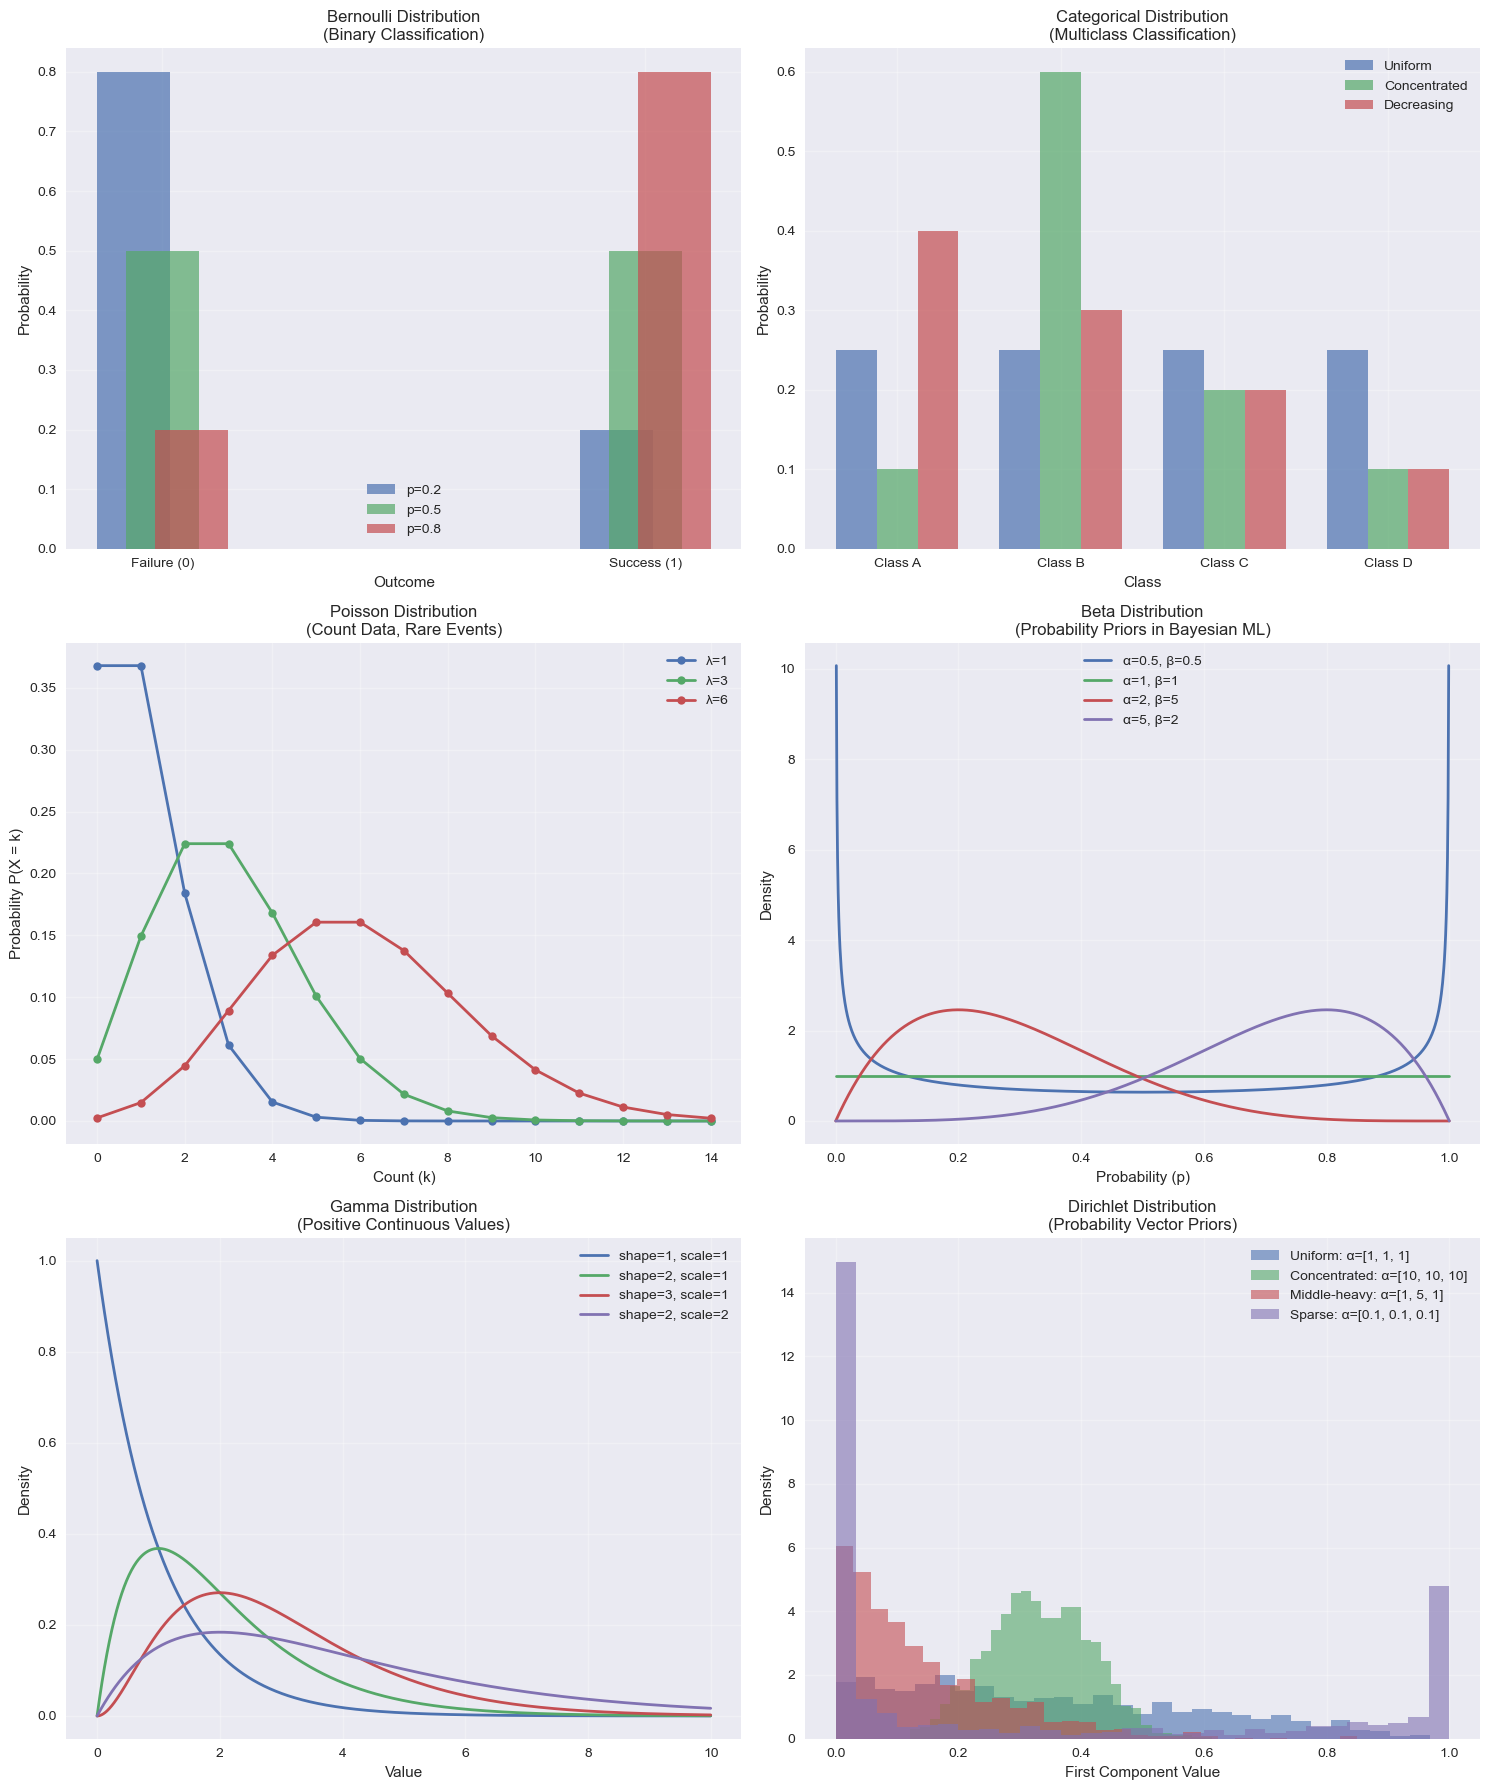


Common Distributions in Machine Learning:
   Distribution       Type                            Parameters                          Use Case                          ML Application
      Bernoulli   Discrete               p (success probability) Binary classification, coin flips              Logistic regression output
    Categorical   Discrete p₁, p₂, ..., pₖ (class probabilities)         Multiclass classification             Softmax output, Naive Bayes
Normal/Gaussian Continuous               μ (mean), σ² (variance)       Continuous features, errors Linear regression, PCA, neural networks
        Poisson   Discrete                    λ (rate parameter)           Count data, rare events        Click prediction, event modeling
           Beta Continuous               α, β (shape parameters) Probabilities as random variables       Bayesian priors for probabilities
      Dirichlet Continuous       α₁, α₂, ..., αₖ (concentration)               Probability vectors    Topic modeling, Bayes

In [9]:
# Common distributions used in machine learning
def plot_ml_distributions():
    """Plot distributions commonly used in ML"""
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 18))
    
    # 1. Bernoulli Distribution (Binary classification)
    ax1 = axes[0, 0]
    p_values = [0.2, 0.5, 0.8]
    x_bernoulli = [0, 1]
    
    for p in p_values:
        pmf = [1-p, p]
        ax1.bar([x-0.1+p*0.2 for x in x_bernoulli], pmf, width=0.15, 
               alpha=0.7, label=f'p={p}')
    
    ax1.set_xlabel('Outcome')
    ax1.set_ylabel('Probability')
    ax1.set_title('Bernoulli Distribution\n(Binary Classification)')
    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(['Failure (0)', 'Success (1)'])
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Categorical Distribution (Multiclass classification)
    ax2 = axes[0, 1]
    categories = ['Class A', 'Class B', 'Class C', 'Class D']
    
    # Different probability vectors
    prob_vectors = [
        [0.25, 0.25, 0.25, 0.25],  # Uniform
        [0.1, 0.6, 0.2, 0.1],      # Concentrated
        [0.4, 0.3, 0.2, 0.1]       # Decreasing
    ]
    labels = ['Uniform', 'Concentrated', 'Decreasing']
    
    x_pos = np.arange(len(categories))
    width = 0.25
    
    for i, (probs, label) in enumerate(zip(prob_vectors, labels)):
        ax2.bar(x_pos + i*width, probs, width, alpha=0.7, label=label)
    
    ax2.set_xlabel('Class')
    ax2.set_ylabel('Probability')
    ax2.set_title('Categorical Distribution\n(Multiclass Classification)')
    ax2.set_xticks(x_pos + width)
    ax2.set_xticklabels(categories)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Poisson Distribution (Count data)
    ax3 = axes[1, 0]
    x_poisson = np.arange(0, 15)
    lambdas = [1, 3, 6]
    
    for lam in lambdas:
        pmf_poisson = stats.poisson.pmf(x_poisson, lam)
        ax3.plot(x_poisson, pmf_poisson, 'o-', linewidth=2, 
                markersize=6, label=f'λ={lam}')
    
    ax3.set_xlabel('Count (k)')
    ax3.set_ylabel('Probability P(X = k)')
    ax3.set_title('Poisson Distribution\n(Count Data, Rare Events)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Beta Distribution (Probability modeling)
    ax4 = axes[1, 1]
    x_beta = np.linspace(0, 1, 1000)
    beta_params = [(0.5, 0.5), (1, 1), (2, 5), (5, 2)]
    
    for alpha, beta in beta_params:
        pdf_beta = stats.beta.pdf(x_beta, alpha, beta)
        ax4.plot(x_beta, pdf_beta, linewidth=2, 
                label=f'α={alpha}, β={beta}')
    
    ax4.set_xlabel('Probability (p)')
    ax4.set_ylabel('Density')
    ax4.set_title('Beta Distribution\n(Probability Priors in Bayesian ML)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Gamma Distribution (Continuous positive values)
    ax5 = axes[2, 0]
    x_gamma = np.linspace(0, 10, 1000)
    gamma_params = [(1, 1), (2, 1), (3, 1), (2, 2)]
    
    for shape, scale in gamma_params:
        pdf_gamma = stats.gamma.pdf(x_gamma, shape, scale=scale)
        ax5.plot(x_gamma, pdf_gamma, linewidth=2, 
                label=f'shape={shape}, scale={scale}')
    
    ax5.set_xlabel('Value')
    ax5.set_ylabel('Density')
    ax5.set_title('Gamma Distribution\n(Positive Continuous Values)')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Dirichlet Distribution (Probability vectors)
    ax6 = axes[2, 1]
    
    # Generate samples from Dirichlet distribution
    np.random.seed(42)
    alpha_params = [
        [1, 1, 1],      # Uniform
        [10, 10, 10],   # Concentrated around uniform
        [1, 5, 1],      # Concentrated on middle
        [0.1, 0.1, 0.1] # Sparse
    ]
    
    labels_dirichlet = ['Uniform', 'Concentrated', 'Middle-heavy', 'Sparse']
    
    for i, (alpha, label) in enumerate(zip(alpha_params, labels_dirichlet)):
        samples = np.random.dirichlet(alpha, 1000)
        
        # Plot the first component
        ax6.hist(samples[:, 0], bins=30, alpha=0.6, density=True, 
                label=f'{label}: α={alpha}')
    
    ax6.set_xlabel('First Component Value')
    ax6.set_ylabel('Density')
    ax6.set_title('Dirichlet Distribution\n(Probability Vector Priors)')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_ml_distributions()

# Create summary table of ML distributions
ml_distributions = [
    {
        'Distribution': 'Bernoulli',
        'Type': 'Discrete',
        'Parameters': 'p (success probability)',
        'Use Case': 'Binary classification, coin flips',
        'ML Application': 'Logistic regression output'
    },
    {
        'Distribution': 'Categorical',
        'Type': 'Discrete',
        'Parameters': 'p₁, p₂, ..., pₖ (class probabilities)',
        'Use Case': 'Multiclass classification',
        'ML Application': 'Softmax output, Naive Bayes'
    },
    {
        'Distribution': 'Normal/Gaussian',
        'Type': 'Continuous',
        'Parameters': 'μ (mean), σ² (variance)',
        'Use Case': 'Continuous features, errors',
        'ML Application': 'Linear regression, PCA, neural networks'
    },
    {
        'Distribution': 'Poisson',
        'Type': 'Discrete',
        'Parameters': 'λ (rate parameter)',
        'Use Case': 'Count data, rare events',
        'ML Application': 'Click prediction, event modeling'
    },
    {
        'Distribution': 'Beta',
        'Type': 'Continuous',
        'Parameters': 'α, β (shape parameters)',
        'Use Case': 'Probabilities as random variables',
        'ML Application': 'Bayesian priors for probabilities'
    },
    {
        'Distribution': 'Dirichlet',
        'Type': 'Continuous',
        'Parameters': 'α₁, α₂, ..., αₖ (concentration)',
        'Use Case': 'Probability vectors',
        'ML Application': 'Topic modeling, Bayesian multinomial'
    }
]

df_distributions = pd.DataFrame(ml_distributions)
print("\nCommon Distributions in Machine Learning:")
print(df_distributions.to_string(index=False))

print(f"\nKey Insights:")
print(f"• Choice of distribution depends on data type and domain knowledge")
print(f"• Normal distribution: Central to many ML algorithms due to CLT")
print(f"• Bernoulli/Categorical: Natural for classification problems")
print(f"• Beta/Dirichlet: Conjugate priors in Bayesian inference")
print(f"• Poisson: Good for modeling rare events and count data")

## 4. Statistical Inference Theory and Maximum Likelihood

### Definition 4.1: Statistical Model
A **statistical model** is a family of probability measures {Pθ : θ ∈ Θ} on a measurable space (𝒳, 𝒜), where:
- 𝒳 is the sample space
- Θ ⊆ ℝᵏ is the parameter space
- θ ↦ Pθ is measurable

The model is **identifiable** if θ ≠ θ' implies Pθ ≠ Pθ'.

### Definition 4.2: Sufficient Statistics
A statistic T: 𝒳ⁿ → ℝᵏ is **sufficient** for θ if:
$$P_\theta(X \in A | T(X) = t) \text{ is independent of } \theta$$

**Factorization Theorem (Neyman-Fisher)**: T is sufficient iff the likelihood factors as:
$$L_n(\theta; x) = g(T(x), \theta) h(x)$$

where g depends on data only through T, and h is independent of θ.

### Definition 4.3: Exponential Families and Complete Statistics
For exponential families with natural form:
$$f(x|\theta) = \exp[\theta^T T(x) - A(\theta) + B(x)]$$

The statistic T is **complete**: if Eθ[g(T)] = 0 for all θ implies g(T) = 0 a.s.

**Theorem**: In regular exponential families, natural sufficient statistics are complete.

### Theorem 4.1: Cramér-Rao Lower Bound
Let θ̂ be an unbiased estimator of θ in a regular model. Then:
$$\text{Var}_\theta(\hat{\theta}) \geq I(\theta)^{-1}$$

where I(θ) is the **Fisher Information Matrix**:
$$I(\theta) = -E_\theta\left[\frac{\partial^2}{\partial \theta^2} \log f(X|\theta)\right] = \text{Var}_\theta\left(\frac{\partial}{\partial \theta} \log f(X|\theta)\right)$$

### Theorem 4.2: Asymptotic Theory of MLE
Under regularity conditions, the MLE θ̂ₙ satisfies:

1. **Consistency**: θ̂ₙ →^P θ₀ (true parameter)

2. **Asymptotic Normality**: 
   $$\sqrt{n}(\hat{\theta}_n - \theta_0) \xrightarrow{d} N(0, I(\theta_0)^{-1})$$

3. **Asymptotic Efficiency**: θ̂ₙ achieves Cramér-Rao bound asymptotically

4. **Invariance**: If g is smooth, then g(θ̂ₙ) is MLE of g(θ₀)

### Definition 4.4: Information-Theoretic Quantities
For distributions P and Q with densities p, q:

**Kullback-Leibler Divergence**:
$$D_{KL}(P \| Q) = \int p(x) \log \frac{p(x)}{q(x)} dx$$

**Mutual Information**:
$$I(X;Y) = D_{KL}(P_{X,Y} \| P_X \otimes P_Y)$$

**Differential Entropy**:
$$h(X) = -\int p(x) \log p(x) dx$$

### Theorem 4.3: Information Processing Inequality
For Markov chain X → Y → Z:
$$I(X;Z) \leq I(X;Y)$$

**Interpretation**: Processing cannot increase information content.

### Definition 4.5: M-Estimation
An **M-estimator** is defined as:
$$\hat{\theta}_n = \arg\min_{\theta \in \Theta} \sum_{i=1}^{n} \rho(X_i, \theta)$$

where ρ is an objective function. MLE corresponds to ρ(x,θ) = -log f(x|θ).

**Asymptotic Theory**: Under regularity conditions:
$$\sqrt{n}(\hat{\theta}_n - \theta_0) \xrightarrow{d} N(0, A(\theta_0)^{-1} B(\theta_0) A(\theta_0)^{-1})$$

where A(θ) = E[∇²ρ(X,θ)] and B(θ) = E[∇ρ(X,θ)∇ρ(X,θ)ᵀ].

In [10]:
# Maximum Likelihood Estimation demonstration
print("Maximum Likelihood Estimation (MLE):")
print("• Goal: Find parameters θ that maximize P(data|θ)")
print("• Likelihood: L(θ) = P(x₁, x₂, ..., xₙ | θ)")
print("• Log-likelihood: ℓ(θ) = log L(θ) = Σᵢ log P(xᵢ | θ)")
print("• MLE: θ̂ = argmax ℓ(θ)")

def mle_normal_distribution():
    """Demonstrate MLE for normal distribution parameters"""
    
    # Generate sample data from known normal distribution
    np.random.seed(42)
    true_mu = 2.5
    true_sigma = 1.2
    n_samples = 100
    
    data = np.random.normal(true_mu, true_sigma, n_samples)
    
    print(f"\nExample: Normal Distribution MLE")
    print(f"True parameters: μ = {true_mu}, σ = {true_sigma}")
    print(f"Sample size: {n_samples}")
    
    # Analytical MLE solutions for normal distribution
    mle_mu = np.mean(data)
    mle_sigma = np.sqrt(np.mean((data - mle_mu)**2))  # MLE uses n, not n-1
    
    print(f"\nMLE estimates:")
    print(f"μ̂ = {mle_mu:.3f} (error: {abs(mle_mu - true_mu):.3f})")
    print(f"σ̂ = {mle_sigma:.3f} (error: {abs(mle_sigma - true_sigma):.3f})")
    
    # Visualize likelihood surface
    def log_likelihood(mu, sigma, data):
        """Calculate log-likelihood for normal distribution"""
        if sigma <= 0:
            return -np.inf
        
        n = len(data)
        log_lik = (-n/2) * np.log(2 * np.pi) - n * np.log(sigma)
        log_lik -= (1/(2*sigma**2)) * np.sum((data - mu)**2)
        return log_lik
    
    # Create parameter grids
    mu_range = np.linspace(true_mu - 1, true_mu + 1, 50)
    sigma_range = np.linspace(0.5, 2.5, 50)
    MU, SIGMA = np.meshgrid(mu_range, sigma_range)
    
    # Calculate log-likelihood surface
    log_lik_surface = np.zeros_like(MU)
    for i in range(MU.shape[0]):
        for j in range(MU.shape[1]):
            log_lik_surface[i, j] = log_likelihood(MU[i, j], SIGMA[i, j], data)
    
    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Data histogram with fitted distributions
    ax1 = axes[0, 0]
    ax1.hist(data, bins=20, density=True, alpha=0.7, color='lightblue', 
             edgecolor='black', label='Sample Data')
    
    x_plot = np.linspace(data.min(), data.max(), 200)
    
    # True distribution
    true_pdf = stats.norm.pdf(x_plot, true_mu, true_sigma)
    ax1.plot(x_plot, true_pdf, 'g-', linewidth=3, label=f'True: μ={true_mu}, σ={true_sigma}')
    
    # MLE fitted distribution
    mle_pdf = stats.norm.pdf(x_plot, mle_mu, mle_sigma)
    ax1.plot(x_plot, mle_pdf, 'r--', linewidth=3, label=f'MLE: μ̂={mle_mu:.2f}, σ̂={mle_sigma:.2f}')
    
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Density')
    ax1.set_title('Data and Fitted Distributions')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Log-likelihood contour
    ax2 = axes[0, 1]
    contour = ax2.contour(MU, SIGMA, log_lik_surface, levels=20)
    ax2.clabel(contour, inline=True, fontsize=8)
    
    # Mark true and MLE parameters
    ax2.plot(true_mu, true_sigma, 'go', markersize=10, label='True parameters')
    ax2.plot(mle_mu, mle_sigma, 'ro', markersize=10, label='MLE estimates')
    
    ax2.set_xlabel('μ')
    ax2.set_ylabel('σ')
    ax2.set_title('Log-Likelihood Contours')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Likelihood vs μ (σ fixed at true value)
    ax3 = axes[1, 0]
    mu_test = np.linspace(true_mu - 1.5, true_mu + 1.5, 100)
    log_lik_mu = [log_likelihood(mu, true_sigma, data) for mu in mu_test]
    
    ax3.plot(mu_test, log_lik_mu, 'b-', linewidth=2)
    ax3.axvline(true_mu, color='green', linestyle='-', linewidth=2, label='True μ')
    ax3.axvline(mle_mu, color='red', linestyle='--', linewidth=2, label='MLE μ̂')
    
    ax3.set_xlabel('μ')
    ax3.set_ylabel('Log-Likelihood')
    ax3.set_title(f'Log-Likelihood vs μ (σ = {true_sigma})')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Likelihood vs σ (μ fixed at true value)
    ax4 = axes[1, 1]
    sigma_test = np.linspace(0.5, 2.5, 100)
    log_lik_sigma = [log_likelihood(true_mu, sigma, data) for sigma in sigma_test]
    
    ax4.plot(sigma_test, log_lik_sigma, 'b-', linewidth=2)
    ax4.axvline(true_sigma, color='green', linestyle='-', linewidth=2, label='True σ')
    ax4.axvline(mle_sigma, color='red', linestyle='--', linewidth=2, label='MLE σ̂')
    
    ax4.set_xlabel('σ')
    ax4.set_ylabel('Log-Likelihood')
    ax4.set_title(f'Log-Likelihood vs σ (μ = {true_mu})')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return data, mle_mu, mle_sigma

data, mle_mu, mle_sigma = mle_normal_distribution()

# Demonstrate convergence properties of MLE
def demonstrate_mle_convergence():
    """Show how MLE estimates improve with sample size"""
    
    np.random.seed(42)
    true_mu = 2.5
    true_sigma = 1.2
    
    # Different sample sizes
    sample_sizes = [10, 30, 100, 300, 1000, 3000]
    n_experiments = 50
    
    results = []
    
    for n in sample_sizes:
        mu_estimates = []
        sigma_estimates = []
        
        for _ in range(n_experiments):
            sample = np.random.normal(true_mu, true_sigma, n)
            mu_est = np.mean(sample)
            sigma_est = np.sqrt(np.mean((sample - mu_est)**2))
            
            mu_estimates.append(mu_est)
            sigma_estimates.append(sigma_est)
        
        results.append({
            'n': n,
            'mu_mean': np.mean(mu_estimates),
            'mu_std': np.std(mu_estimates),
            'sigma_mean': np.mean(sigma_estimates),
            'sigma_std': np.std(sigma_estimates)
        })
    
    # Plot convergence
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: μ estimates
    ax1 = axes[0]
    n_values = [r['n'] for r in results]
    mu_means = [r['mu_mean'] for r in results]
    mu_stds = [r['mu_std'] for r in results]
    
    ax1.errorbar(n_values, mu_means, yerr=mu_stds, 'bo-', capsize=5, 
                capthick=2, linewidth=2, markersize=6)
    ax1.axhline(true_mu, color='red', linestyle='--', linewidth=2, label=f'True μ = {true_mu}')
    
    ax1.set_xlabel('Sample Size')
    ax1.set_ylabel('MLE Estimate of μ')
    ax1.set_title('Convergence of μ̂ to True μ')
    ax1.set_xscale('log')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: σ estimates
    ax2 = axes[1]
    sigma_means = [r['sigma_mean'] for r in results]
    sigma_stds = [r['sigma_std'] for r in results]
    
    ax2.errorbar(n_values, sigma_means, yerr=sigma_stds, 'go-', capsize=5, 
                capthick=2, linewidth=2, markersize=6)
    ax2.axhline(true_sigma, color='red', linestyle='--', linewidth=2, label=f'True σ = {true_sigma}')
    
    ax2.set_xlabel('Sample Size')
    ax2.set_ylabel('MLE Estimate of σ')
    ax2.set_title('Convergence of σ̂ to True σ')
    ax2.set_xscale('log')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print convergence statistics
    print(f"\nMLE Convergence Analysis:")
    print(f"Sample Size | μ̂ (±std) | σ̂ (±std) | μ error | σ error")
    print("-" * 60)
    for r in results:
        mu_error = abs(r['mu_mean'] - true_mu)
        sigma_error = abs(r['sigma_mean'] - true_sigma)
        print(f"{r['n']:10d} | {r['mu_mean']:6.3f} (±{r['mu_std']:.3f}) | "
              f"{r['sigma_mean']:6.3f} (±{r['sigma_std']:.3f}) | "
              f"{mu_error:7.4f} | {sigma_error:7.4f}")

demonstrate_mle_convergence()

print(f"\nMLE Properties:")
print(f"• Consistency: θ̂ → θ as n → ∞")
print(f"• Asymptotic normality: θ̂ ~ N(θ, I⁻¹(θ)/n) for large n")
print(f"• Efficiency: Achieves Cramér-Rao lower bound")
print(f"• Invariance: If θ̂ is MLE of θ, then g(θ̂) is MLE of g(θ)")

SyntaxError: positional argument follows keyword argument (1559384952.py, line 173)

### MLE in Machine Learning Applications


Logistic Regression MLE Example:
Data: 500 samples, 2 features + bias
True weights: [ 1.5 -0.8  0.5]
Class distribution: 0.790 positive

MLE Results:
Iterations: 38
True weights: [ 1.5 -0.8  0.5]
MLE weights:  [ 1.57782664 -0.83428871  0.63878642]
Weight errors: [0.07782664 0.03428871 0.13878642]


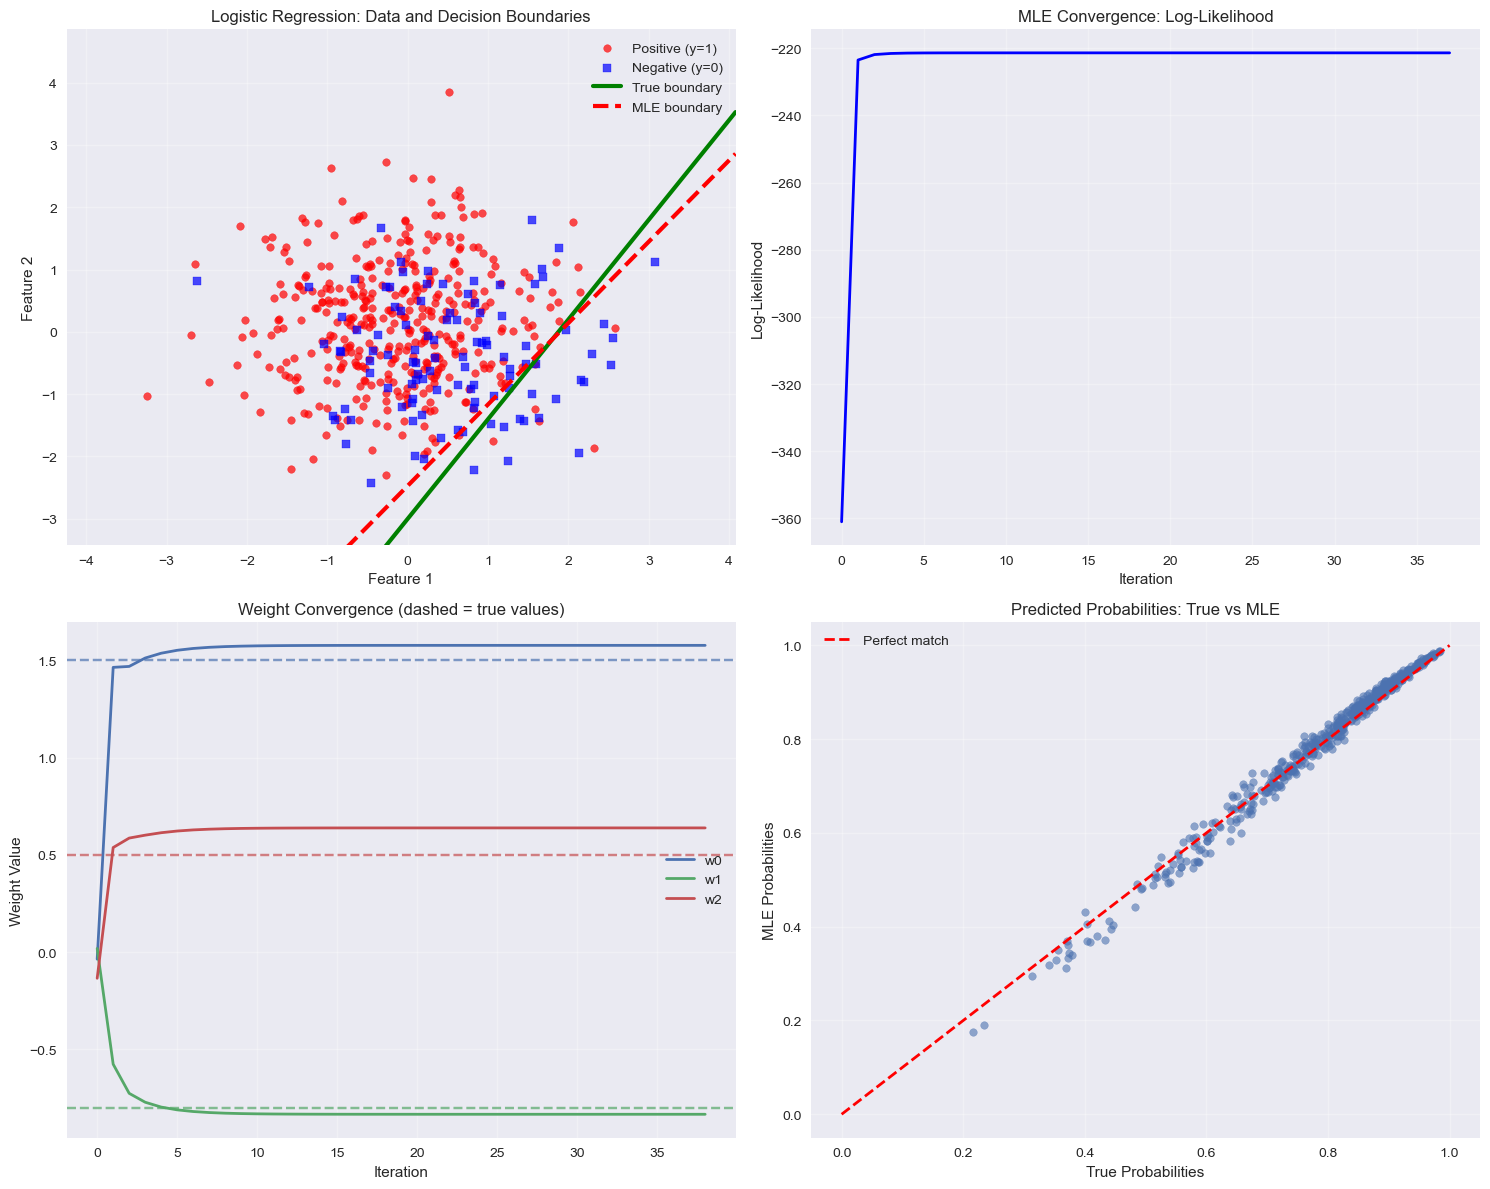


Model Performance:
Accuracy: 0.818
Final log-likelihood: -221.414

MLE in Machine Learning:
• Linear Regression: MLE gives least squares solution
• Logistic Regression: MLE via gradient ascent/descent
• Neural Networks: MLE provides theoretical foundation for training
• Naive Bayes: MLE for estimating class and feature probabilities
• Gaussian Mixture Models: EM algorithm for MLE


In [11]:
# MLE applications in machine learning
def mle_logistic_regression():
    """Demonstrate MLE in logistic regression"""
    
    # Generate binary classification data
    np.random.seed(42)
    n_samples = 500
    
    # Generate features
    X = np.random.randn(n_samples, 2)
    
    # True logistic regression parameters
    true_w = np.array([1.5, -0.8, 0.5])  # Including bias
    
    # Add bias column
    X_with_bias = np.column_stack([np.ones(n_samples), X])
    
    # Generate labels using logistic function
    logits = X_with_bias @ true_w
    probabilities = 1 / (1 + np.exp(-logits))
    y = np.random.binomial(1, probabilities)
    
    print(f"\nLogistic Regression MLE Example:")
    print(f"Data: {n_samples} samples, 2 features + bias")
    print(f"True weights: {true_w}")
    print(f"Class distribution: {np.mean(y):.3f} positive")
    
    def sigmoid(z):
        """Sigmoid function with numerical stability"""
        z = np.clip(z, -250, 250)  # Prevent overflow
        return 1 / (1 + np.exp(-z))
    
    def log_likelihood_logistic(w, X, y):
        """Log-likelihood for logistic regression"""
        z = X @ w
        p = sigmoid(z)
        
        # Avoid log(0) by adding small epsilon
        eps = 1e-15
        p = np.clip(p, eps, 1 - eps)
        
        return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
    
    def gradient_logistic(w, X, y):
        """Gradient of log-likelihood for logistic regression"""
        z = X @ w
        p = sigmoid(z)
        return X.T @ (y - p)
    
    # Implement gradient ascent for MLE
    def mle_gradient_ascent(X, y, learning_rate=0.01, max_iter=1000, tolerance=1e-6):
        """Find MLE using gradient ascent"""
        w = np.random.randn(X.shape[1]) * 0.1  # Initialize weights
        
        history = {'weights': [w.copy()], 'log_likelihood': []}
        
        for i in range(max_iter):
            # Calculate current log-likelihood
            log_lik = log_likelihood_logistic(w, X, y)
            history['log_likelihood'].append(log_lik)
            
            # Calculate gradient
            grad = gradient_logistic(w, X, y)
            
            # Update weights (gradient ascent)
            w = w + learning_rate * grad
            history['weights'].append(w.copy())
            
            # Check convergence
            if np.linalg.norm(grad) < tolerance:
                break
        
        return w, history, i+1
    
    # Find MLE
    mle_weights, history, iterations = mle_gradient_ascent(X_with_bias, y)
    
    print(f"\nMLE Results:")
    print(f"Iterations: {iterations}")
    print(f"True weights: {true_w}")
    print(f"MLE weights:  {mle_weights}")
    print(f"Weight errors: {np.abs(mle_weights - true_w)}")
    
    # Visualize results
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Data and decision boundary
    ax1 = axes[0, 0]
    
    # Plot data points
    pos_mask = y == 1
    neg_mask = y == 0
    
    ax1.scatter(X[pos_mask, 0], X[pos_mask, 1], c='red', marker='o', 
               alpha=0.7, s=30, label='Positive (y=1)')
    ax1.scatter(X[neg_mask, 0], X[neg_mask, 1], c='blue', marker='s', 
               alpha=0.7, s=30, label='Negative (y=0)')
    
    # Plot decision boundaries
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # True decision boundary: w0 + w1*x1 + w2*x2 = 0
    x1_line = np.array([x_min, x_max])
    x2_true = -(true_w[0] + true_w[1] * x1_line) / true_w[2]
    ax1.plot(x1_line, x2_true, 'g-', linewidth=3, label='True boundary')
    
    # MLE decision boundary
    x2_mle = -(mle_weights[0] + mle_weights[1] * x1_line) / mle_weights[2]
    ax1.plot(x1_line, x2_mle, 'r--', linewidth=3, label='MLE boundary')
    
    ax1.set_xlabel('Feature 1')
    ax1.set_ylabel('Feature 2')
    ax1.set_title('Logistic Regression: Data and Decision Boundaries')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    
    # Plot 2: Log-likelihood convergence
    ax2 = axes[0, 1]
    ax2.plot(history['log_likelihood'], 'b-', linewidth=2)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Log-Likelihood')
    ax2.set_title('MLE Convergence: Log-Likelihood')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Weight convergence
    ax3 = axes[1, 0]
    weights_array = np.array(history['weights'])
    
    for i in range(len(true_w)):
        ax3.plot(weights_array[:, i], linewidth=2, label=f'w{i}')
        ax3.axhline(true_w[i], color=f'C{i}', linestyle='--', alpha=0.7)
    
    ax3.set_xlabel('Iteration')
    ax3.set_ylabel('Weight Value')
    ax3.set_title('Weight Convergence (dashed = true values)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Prediction probabilities
    ax4 = axes[1, 1]
    
    # Calculate prediction probabilities
    true_probs = sigmoid(X_with_bias @ true_w)
    mle_probs = sigmoid(X_with_bias @ mle_weights)
    
    ax4.scatter(true_probs, mle_probs, alpha=0.6, s=30)
    ax4.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect match')
    
    ax4.set_xlabel('True Probabilities')
    ax4.set_ylabel('MLE Probabilities')
    ax4.set_title('Predicted Probabilities: True vs MLE')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate accuracy
    predictions = (mle_probs > 0.5).astype(int)
    accuracy = np.mean(predictions == y)
    
    print(f"\nModel Performance:")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Final log-likelihood: {history['log_likelihood'][-1]:.3f}")
    
    return mle_weights, history

mle_weights, history = mle_logistic_regression()

print(f"\nMLE in Machine Learning:")
print(f"• Linear Regression: MLE gives least squares solution")
print(f"• Logistic Regression: MLE via gradient ascent/descent")
print(f"• Neural Networks: MLE provides theoretical foundation for training")
print(f"• Naive Bayes: MLE for estimating class and feature probabilities")
print(f"• Gaussian Mixture Models: EM algorithm for MLE")

## Summary: Theoretical Foundations and Machine Learning Connections

This comprehensive treatment of probability and statistics provides the rigorous mathematical foundations essential for advanced machine learning and statistical inference. The measure-theoretic approach enables understanding of infinite-dimensional problems, stochastic processes, and modern statistical learning theory.

### Core Theoretical Achievements:

**1. Measure-Theoretic Foundation:**
- **Kolmogorov's Axioms**: Rigorous foundation for all probability theory
- **Random Variables**: Measurable functions providing link between abstract probability and concrete applications
- **Convergence Modes**: Essential for understanding consistency and limit theorems in ML
- **Integration Theory**: Foundation for expectations, conditional expectation, and martingale theory

**2. Advanced Probability Theory:**
- **Conditional Expectation**: Fundamental for prediction theory, filtering, and Bayesian inference
- **Characteristic Functions**: Complete characterization of distributions, essential for limit theorems
- **Information Theory**: Quantifies uncertainty, provides bounds for learning and compression
- **Large Deviations**: Exponential concentration inequalities crucial for generalization bounds

**3. Statistical Inference:**
- **Exponential Families**: Unifying framework for parametric models in ML
- **Sufficient Statistics**: Optimal dimensionality reduction preserving all information
- **Fisher Information**: Fundamental limits on estimation accuracy
- **Asymptotic Theory**: Justification for approximate inference in high-dimensional settings

### Deep Connections to Machine Learning:

**Statistical Learning Theory:**
- **PAC Learning**: Probability distributions over instance-label pairs
- **Empirical Risk Minimization**: M-estimation framework with convex loss functions  
- **Generalization Bounds**: Concentration inequalities (Hoeffding, McDiarmid, Rademacher)
- **Model Selection**: Information criteria (AIC, BIC) based on likelihood theory

**Bayesian Machine Learning:**
- **Prior/Posterior**: Conditional probability with parameter distributions
- **Conjugate Priors**: Exponential family structure enables closed-form inference
- **Markov Chain Monte Carlo**: Advanced sampling from complex posteriors
- **Variational Inference**: Optimization-based approximation to intractable posteriors

**Deep Learning Foundations:**
- **Universal Approximation**: Measure theory provides function space framework
- **Stochastic Gradient Descent**: Stochastic approximation theory and martingale convergence
- **Regularization**: Bayesian perspective connects L₂ penalty with Gaussian priors
- **Information Bottleneck**: Rate-distortion theory applied to representation learning

**Advanced Topics:**
- **Kernel Methods**: Reproducing Kernel Hilbert Spaces and measure theory
- **Gaussian Processes**: Infinite-dimensional probability theory
- **Reinforcement Learning**: Markov Decision Processes and optimal control theory
- **Causal Inference**: Conditional independence and graphical models

### Research Frontiers:

**Theoretical Machine Learning:**
- **Non-convex Optimization**: Landscape analysis using concentration inequalities
- **High-dimensional Statistics**: Curse of dimensionality and blessing of concentration
- **Online Learning**: Martingale theory and adaptive algorithms
- **Transfer Learning**: Distribution shift and domain adaptation theory

**Modern Applications:**
- **Deep Generative Models**: VAEs use variational inference, GANs use divergence minimization
- **Transformer Architecture**: Attention mechanisms as conditional probability weights
- **Uncertainty Quantification**: Bayesian deep learning and ensemble methods
- **Federated Learning**: Distributed statistical inference with communication constraints

### Critical Research Questions:

1. **Generalization**: How do measure-theoretic concentration inequalities extend to infinite-dimensional parameter spaces?

2. **Computational Complexity**: What are fundamental limits relating statistical and computational efficiency?

3. **Robust Statistics**: How do adversarial perturbations relate to robust statistical methods?

4. **Causality**: Can we extend Pearl's causal hierarchy using more sophisticated probability theory?

This theoretical foundation enables rigorous analysis of modern machine learning algorithms, providing both mathematical tools for algorithm design and theoretical guarantees for performance. The measure-theoretic approach is essential for understanding infinite-dimensional problems that arise in deep learning, Gaussian processes, and functional data analysis.

**Next Steps**: With this foundation, you are prepared for advanced topics including stochastic processes, functional analysis applications to ML, optimal transport in machine learning, and modern statistical learning theory including PAC-Bayes bounds and algorithmic stability.